## Find limit cycle Gamma and then visualize

Step 1: Finding the limit cycle...
✓ Transient integration complete (t=0 to 5000)
  Final state: S=0.278623, I=0.000084, v=0.000000

Step 2: Estimating period...
✓ Found 2 peaks
  Estimated period T ≈ 244.2876

Step 3: Computing one clean period...
✓ One period computed with 1000 points
  Period T = 244.2876
  Starting point: S=0.285487, I=0.033982, v=0.692689
  Ending point:   S=0.286113, I=0.033981, v=0.686465
  Periodicity error: 6.26e-03

Step 4: Visualizing...


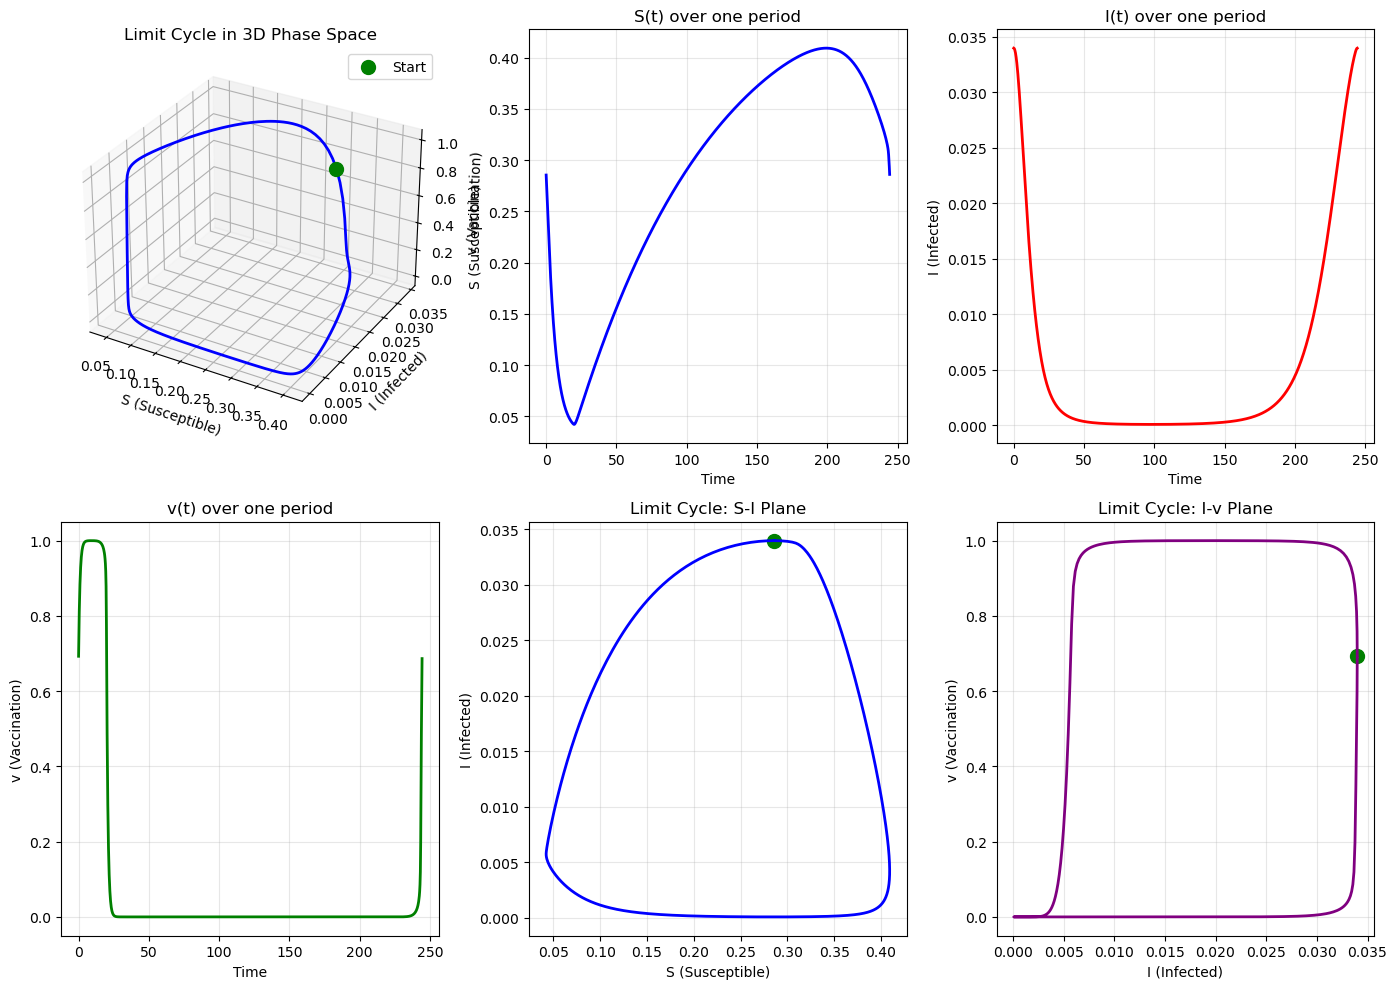


SUCCESS! Limit cycle computed and stored in 'Gamma'

Next step: Compute the adjoint solution Z(t) using equation (2.2)
This will give us the iPRC (infinitesimal phase response curve)


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ----------------------------
# Parameters
# ----------------------------
alpha = 1/100
beta = 0.5
gamma = 1/7
epsilon = 1/7
theta = 0.01
kappa = 1000
rho = 0.01
psi = 0.5

# Smooth Heaviside function
def H(q):
    return 1 / (1 + np.exp(-kappa * q))

# ----------------------------
# System of ODEs
# ----------------------------
def system(t, y):
    S, I, v = y
    q = beta * I - rho - theta * (1 - 2 * v)
    
    dS = alpha * (psi - S - I) - beta * S * I - epsilon * v * S
    dI = -gamma * I + beta * S * I
    dv = -v + H(q)
    
    return [dS, dI, dv]

# ----------------------------
# Step 1: Integrate for a long time to reach limit cycle
# ----------------------------
print("Step 1: Finding the limit cycle...")
print("=" * 60)

# Initial conditions
S0, I0, v0 = 0.49, 0.01, 0.01
y0 = [S0, I0, v0]

# Integrate for a long time to let transients die out
t_transient = 5000  # integrate for long time
sol_transient = solve_ivp(
    system, 
    [0, t_transient], 
    y0,
    dense_output=True,
    rtol=1e-10,
    atol=1e-12
)

print(f"✓ Transient integration complete (t=0 to {t_transient})")
print(f"  Final state: S={sol_transient.y[0,-1]:.6f}, I={sol_transient.y[1,-1]:.6f}, v={sol_transient.y[2,-1]:.6f}")

# ----------------------------
# Step 2: Find the period by detecting crossings
# ----------------------------
print("\nStep 2: Estimating period...")
print("=" * 60)

# Start from end of transient and integrate more
y_start = sol_transient.y[:, -1]
t_span_period = 500
sol_period = solve_ivp(
    system,
    [0, t_span_period],
    y_start,
    dense_output=True,
    max_step=0.1,
    rtol=1e-10,
    atol=1e-12
)

# Find period by looking for when I returns to same value
# (detecting maxima of I)
I_vals = sol_period.y[1, :]
t_vals = sol_period.t

# Find local maxima (peaks)
from scipy.signal import find_peaks
peaks, _ = find_peaks(I_vals, height=0.01, distance=50)

if len(peaks) >= 2:
    # Estimate period from peak spacing
    periods = np.diff(t_vals[peaks])
    T_estimated = np.mean(periods)
    print(f"✓ Found {len(peaks)} peaks")
    print(f"  Estimated period T ≈ {T_estimated:.4f}")
else:
    print("⚠ Warning: Could not detect clear peaks. Using default estimate.")
    T_estimated = 100.0

# ----------------------------
# Step 3: Integrate for exactly one period
# ----------------------------
print("\nStep 3: Computing one clean period...")
print("=" * 60)

# Start fresh from the limit cycle
y_start_clean = sol_period.y[:, peaks[0]] if len(peaks) > 0 else y_start

# Integrate for one period with many points
n_points = 1000
t_one_period = np.linspace(0, T_estimated, n_points)

sol_one_period = solve_ivp(
    system,
    [0, T_estimated],
    y_start_clean,
    t_eval=t_one_period,
    rtol=1e-10,
    atol=1e-12
)

# Store as Gamma (your limit cycle)
Gamma = np.zeros((n_points, 4))  # [time, S, I, v]
Gamma[:, 0] = sol_one_period.t
Gamma[:, 1] = sol_one_period.y[0, :]  # S
Gamma[:, 2] = sol_one_period.y[1, :]  # I
Gamma[:, 3] = sol_one_period.y[2, :]  # v

print(f"✓ One period computed with {n_points} points")
print(f"  Period T = {T_estimated:.4f}")
print(f"  Starting point: S={Gamma[0,1]:.6f}, I={Gamma[0,2]:.6f}, v={Gamma[0,3]:.6f}")
print(f"  Ending point:   S={Gamma[-1,1]:.6f}, I={Gamma[-1,2]:.6f}, v={Gamma[-1,3]:.6f}")

# Check if it's actually periodic (start ≈ end)
error = np.linalg.norm(Gamma[0, 1:] - Gamma[-1, 1:])
print(f"  Periodicity error: {error:.2e}")

# ----------------------------
# Step 4: Visualize the limit cycle
# ----------------------------
print("\nStep 4: Visualizing...")
print("=" * 60)

fig = plt.figure(figsize=(14, 10))

# 3D phase space
ax1 = fig.add_subplot(2, 3, 1, projection='3d')
ax1.plot(Gamma[:, 1], Gamma[:, 2], Gamma[:, 3], 'b-', linewidth=2)
ax1.scatter(Gamma[0, 1], Gamma[0, 2], Gamma[0, 3], c='green', s=100, marker='o', label='Start')
ax1.set_xlabel('S (Susceptible)')
ax1.set_ylabel('I (Infected)')
ax1.set_zlabel('v (Vaccination)')
ax1.set_title('Limit Cycle in 3D Phase Space')
ax1.legend()

# Time series - S
ax2 = fig.add_subplot(2, 3, 2)
ax2.plot(Gamma[:, 0], Gamma[:, 1], 'b-', linewidth=2)
ax2.set_xlabel('Time')
ax2.set_ylabel('S (Susceptible)')
ax2.set_title('S(t) over one period')
ax2.grid(True, alpha=0.3)

# Time series - I
ax3 = fig.add_subplot(2, 3, 3)
ax3.plot(Gamma[:, 0], Gamma[:, 2], 'r-', linewidth=2)
ax3.set_xlabel('Time')
ax3.set_ylabel('I (Infected)')
ax3.set_title('I(t) over one period')
ax3.grid(True, alpha=0.3)

# Time series - v
ax4 = fig.add_subplot(2, 3, 4)
ax4.plot(Gamma[:, 0], Gamma[:, 3], 'g-', linewidth=2)
ax4.set_xlabel('Time')
ax4.set_ylabel('v (Vaccination)')
ax4.set_title('v(t) over one period')
ax4.grid(True, alpha=0.3)

# S-I plane
ax5 = fig.add_subplot(2, 3, 5)
ax5.plot(Gamma[:, 1], Gamma[:, 2], 'b-', linewidth=2)
ax5.scatter(Gamma[0, 1], Gamma[0, 2], c='green', s=100, marker='o')
ax5.set_xlabel('S (Susceptible)')
ax5.set_ylabel('I (Infected)')
ax5.set_title('Limit Cycle: S-I Plane')
ax5.grid(True, alpha=0.3)

# I-v plane
ax6 = fig.add_subplot(2, 3, 6)
ax6.plot(Gamma[:, 2], Gamma[:, 3], 'purple', linewidth=2)
ax6.scatter(Gamma[0, 2], Gamma[0, 3], c='green', s=100, marker='o')
ax6.set_xlabel('I (Infected)')
ax6.set_ylabel('v (Vaccination)')
ax6.set_title('Limit Cycle: I-v Plane')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("SUCCESS! Limit cycle computed and stored in 'Gamma'")
print("=" * 60)
print("\nNext step: Compute the adjoint solution Z(t) using equation (2.2)")
print("This will give us the iPRC (infinitesimal phase response curve)")

STEP 2A: Computing Jacobian A(t)

Computing Jacobian at 1000 points along limit cycle...
✓ Jacobian computed at all points!

Sanity check - A(t) at a few time points:
------------------------------------------------------------

Time t = 0.00:
  State: S=0.2855, I=0.0340, v=0.6927
  A(t) =
[[-1.25946301e-01 -1.52743532e-01 -4.07838664e-02]
 [ 1.69907595e-02 -1.13610398e-04  0.00000000e+00]
 [ 0.00000000e+00  9.75508867e-03 -9.99609796e-01]]

Time t = 61.13:
  State: S=0.1918, I=0.0002, v=0.0000
  A(t) =
[[-1.00934709e-02 -1.05921131e-01 -2.74060376e-02]
 [ 9.34705941e-05 -4.69360114e-02  0.00000000e+00]
 [ 0.00000000e+00  1.13155104e-06 -9.99999955e-01]]

Time t = 122.27:
  State: S=0.3321, I=0.0001, v=0.0000
  A(t) =
[[-1.00562217e-02 -1.76055398e-01 -4.74443994e-02]
 [ 5.62214249e-05  2.31982551e-02  0.00000000e+00]
 [ 0.00000000e+00  1.09017706e-06 -9.99999956e-01]]

Time t = 183.40:
  State: S=0.4038, I=0.0016, v=0.0000
  A(t) =
[[-1.08089013e-02 -2.11879850e-01 -5.76799571e-02]
 [

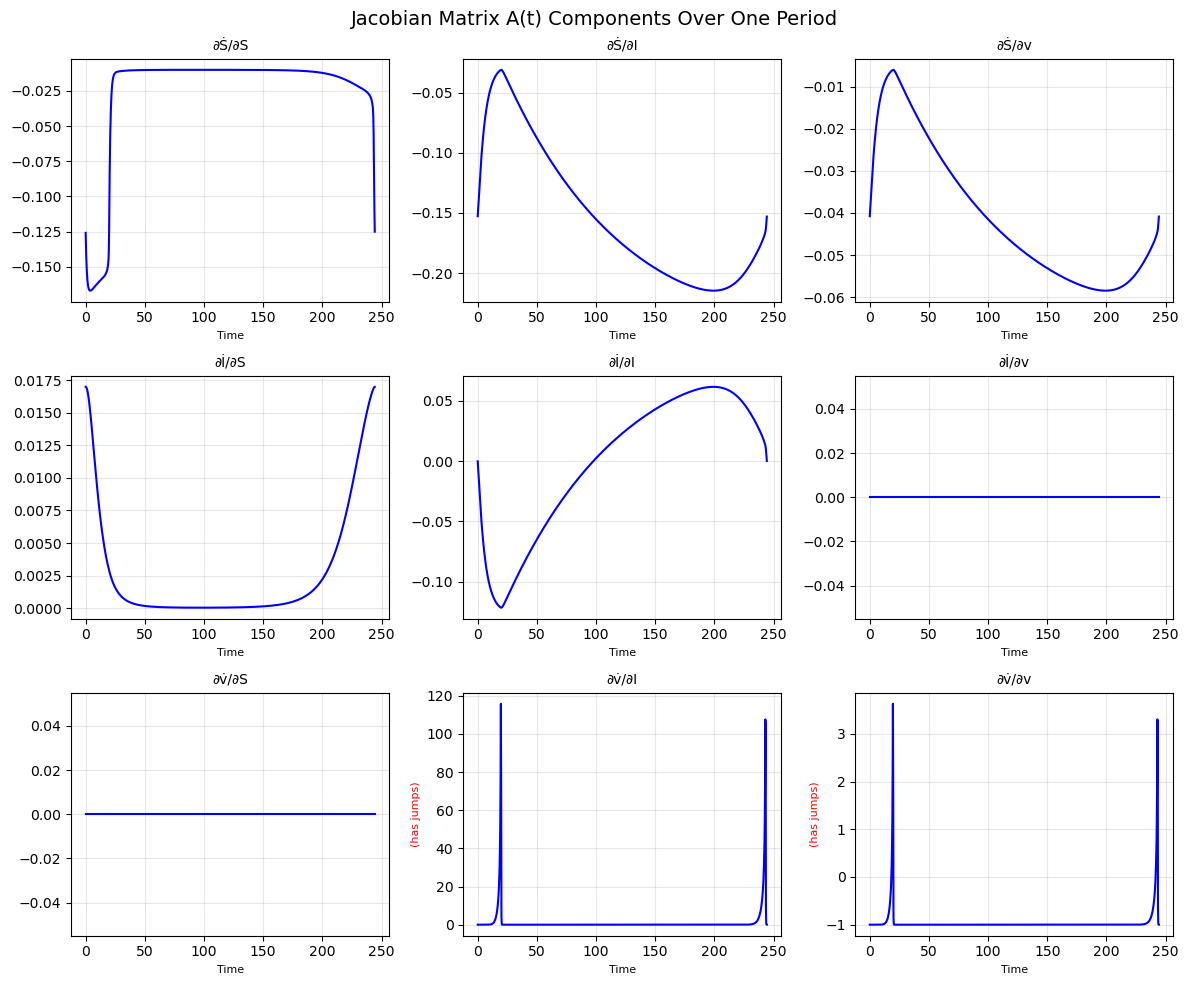


STEP 2A COMPLETE!
✓ We now have A_trajectory with shape: (1000, 3, 3)
  This contains A(t) at each point on the limit cycle

Next: Step 2B - Detect switching surface crossings


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Assume we already have:
# - Gamma: array of shape (n_points, 4) with columns [time, S, I, v]
# - T_estimated: the period
# - All parameters: alpha, beta, gamma, epsilon, theta, kappa, rho, psi

# ----------------------------
# Parameters (copy from before)
# ----------------------------
alpha = 1/100
beta = 0.5
gamma_param = 1/7  # renamed to avoid conflict with Gamma array
epsilon = 1/7
theta = 0.01
kappa = 1000
rho = 0.01
psi = 0.5

print("=" * 60)
print("STEP 2A: Computing Jacobian A(t)")
print("=" * 60)

# ----------------------------
# Derivatives of H(q) with respect to q
# ----------------------------
def H(q):
    """Smooth Heaviside"""
    return 1 / (1 + np.exp(-kappa * q))

def dH_dq(q):
    """Derivative of H with respect to q"""
    exp_term = np.exp(-kappa * q)
    return kappa * exp_term / (1 + exp_term)**2

# ----------------------------
# Compute Jacobian A at a single point (S, I, v)
# ----------------------------
def compute_jacobian(S, I, v):
    """
    Compute the Jacobian matrix A = DF evaluated at (S, I, v)
    
    The system is:
        dS/dt = alpha*(psi - S - I) - beta*S*I - epsilon*v*S
        dI/dt = -gamma*I + beta*S*I
        dv/dt = -v + H(q),  where q = beta*I - rho - theta*(1 - 2*v)
    
    Returns: 3x3 numpy array
    """
    # First, compute q and dH/dq at this point
    q = beta * I - rho - theta * (1 - 2 * v)
    dH_dq_val = dH_dq(q)
    
    # Now compute all partial derivatives
    # Row 1: derivatives of dS/dt
    dS_dS = -alpha - beta * I - epsilon * v
    dS_dI = -alpha - beta * S
    dS_dv = -epsilon * S
    
    # Row 2: derivatives of dI/dt
    dI_dS = beta * I
    dI_dI = -gamma_param + beta * S
    dI_dv = 0
    
    # Row 3: derivatives of dv/dt
    # dv/dt = -v + H(q), where q = beta*I - rho - theta*(1 - 2*v)
    # So: ∂(dv/dt)/∂S = 0
    #     ∂(dv/dt)/∂I = dH/dq * ∂q/∂I = dH/dq * beta
    #     ∂(dv/dt)/∂v = -1 + dH/dq * ∂q/∂v = -1 + dH/dq * 2*theta
    
    dv_dS = 0
    dv_dI = dH_dq_val * beta
    dv_dv = -1 + dH_dq_val * 2 * theta
    
    # Assemble the Jacobian
    A = np.array([
        [dS_dS, dS_dI, dS_dv],
        [dI_dS, dI_dI, dI_dv],
        [dv_dS, dv_dI, dv_dv]
    ])
    
    return A

# ----------------------------
# Compute A(t) for all points on the limit cycle
# ----------------------------
n_points = Gamma.shape[0]
A_trajectory = np.zeros((n_points, 3, 3))

print(f"\nComputing Jacobian at {n_points} points along limit cycle...")

for i in range(n_points):
    S_i = Gamma[i, 1]
    I_i = Gamma[i, 2]
    v_i = Gamma[i, 3]
    
    A_trajectory[i, :, :] = compute_jacobian(S_i, I_i, v_i)

print("✓ Jacobian computed at all points!")

# ----------------------------
# Sanity check: show A at a few points
# ----------------------------
print("\nSanity check - A(t) at a few time points:")
print("-" * 60)

for idx in [0, n_points//4, n_points//2, 3*n_points//4]:
    print(f"\nTime t = {Gamma[idx, 0]:.2f}:")
    print(f"  State: S={Gamma[idx, 1]:.4f}, I={Gamma[idx, 2]:.4f}, v={Gamma[idx, 3]:.4f}")
    print(f"  A(t) =")
    print(A_trajectory[idx])

# ----------------------------
# Visualize one element of A(t) over time
# ----------------------------
print("\nVisualizing A(t) components over time...")

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle('Jacobian Matrix A(t) Components Over One Period', fontsize=14)

component_names = [
    ['∂Ṡ/∂S', '∂Ṡ/∂I', '∂Ṡ/∂v'],
    ['∂İ/∂S', '∂İ/∂I', '∂İ/∂v'],
    ['∂v̇/∂S', '∂v̇/∂I', '∂v̇/∂v']
]

for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        ax.plot(Gamma[:, 0], A_trajectory[:, i, j], 'b-', linewidth=1.5)
        ax.set_title(component_names[i][j], fontsize=10)
        ax.set_xlabel('Time', fontsize=8)
        ax.grid(True, alpha=0.3)
        
        # Highlight if there are jumps (near switching surface)
        if np.max(np.abs(np.diff(A_trajectory[:, i, j]))) > 1:
            ax.set_ylabel('(has jumps)', fontsize=8, color='red')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("STEP 2A COMPLETE!")
print("=" * 60)
print("✓ We now have A_trajectory with shape:", A_trajectory.shape)
print("  This contains A(t) at each point on the limit cycle")
print("\nNext: Step 2B - Detect switching surface crossings")

STEP 2B: Detecting Switching Surface Crossings

Computing q(t) = βI - ρ - θ(1 - 2v) along limit cycle...
✓ Computed q(t) at 1000 points
  Range: [-0.019958, 0.015635]

Finding where q(t) crosses zero...
✓ Found 2 zero crossings!

Crossing details:
------------------------------------------------------------

Crossing 1:
  Time: t = 19.6275
  Direction: ↓ (q: + to -)
  Between indices 80 and 81
  q changes from 0.000558 to -0.001544
  State (approx): S=0.0424, I=0.0060, v=0.8786

Crossing 2:
  Time: t = 243.1819
  Direction: ↑ (q: - to +)
  Between indices 994 and 995
  q changes from -0.000785 to 0.000856
  State (approx): S=0.3115, I=0.0337, v=0.1193

Visualizing q(t) and crossings...


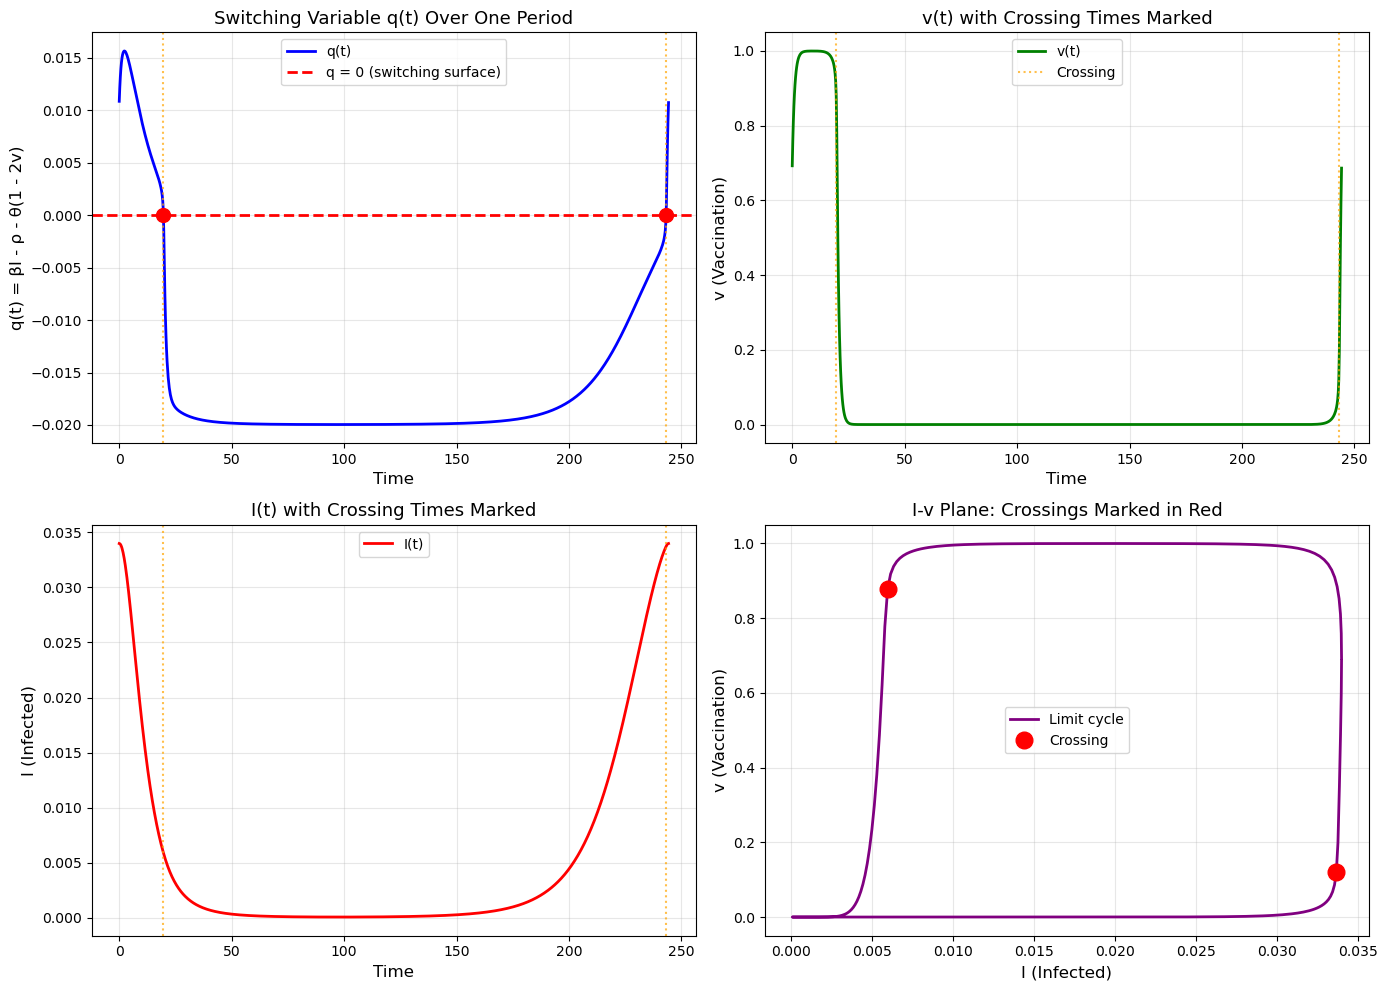


STEP 2B COMPLETE!
✓ Found 2 crossings of q = 0
✓ Crossing information stored in 'crossings' list

Next: Step 2C - Integrate adjoint equation backwards with saltation corrections


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Assume we have from previous steps:
# - Gamma: limit cycle data
# - beta, rho, theta: parameters

# Parameters (copy from before)
beta = 0.5
rho = 0.01
theta = 0.01

print("=" * 60)
print("STEP 2B: Detecting Switching Surface Crossings")
print("=" * 60)

# ----------------------------
# Compute q(t) along the limit cycle
# ----------------------------
print("\nComputing q(t) = βI - ρ - θ(1 - 2v) along limit cycle...")

n_points = Gamma.shape[0]
q_trajectory = np.zeros(n_points)

for i in range(n_points):
    I_i = Gamma[i, 2]  # Infected
    v_i = Gamma[i, 3]  # Vaccination
    q_trajectory[i] = beta * I_i - rho - theta * (1 - 2 * v_i)

print(f"✓ Computed q(t) at {n_points} points")
print(f"  Range: [{np.min(q_trajectory):.6f}, {np.max(q_trajectory):.6f}]")

# ----------------------------
# Find zero crossings of q(t)
# ----------------------------
print("\nFinding where q(t) crosses zero...")

# A crossing occurs when q changes sign between consecutive points
# q[i] * q[i+1] < 0 means a crossing happened

crossings = []
crossing_indices = []
crossing_directions = []  # +1 for upward crossing, -1 for downward

for i in range(n_points - 1):
    if q_trajectory[i] * q_trajectory[i+1] < 0:
        # Zero crossing detected between index i and i+1
        
        # Interpolate to find exact crossing time
        # Linear interpolation: t_cross = t[i] + (t[i+1] - t[i]) * |q[i]| / (|q[i]| + |q[i+1]|)
        t_i = Gamma[i, 0]
        t_i1 = Gamma[i+1, 0]
        q_i = q_trajectory[i]
        q_i1 = q_trajectory[i+1]
        
        # Fraction between i and i+1 where q = 0
        fraction = abs(q_i) / (abs(q_i) + abs(q_i1))
        t_cross = t_i + fraction * (t_i1 - t_i)
        
        # Direction: positive if going from negative to positive
        direction = +1 if q_i1 > q_i else -1
        
        crossings.append({
            'time': t_cross,
            'index_before': i,
            'index_after': i+1,
            'direction': direction,
            'q_before': q_i,
            'q_after': q_i1
        })
        crossing_indices.append(i)
        crossing_directions.append(direction)

num_crossings = len(crossings)
print(f"✓ Found {num_crossings} zero crossings!")

# ----------------------------
# Display crossing information
# ----------------------------
print("\nCrossing details:")
print("-" * 60)

for idx, cross in enumerate(crossings):
    direction_str = "↑ (q: - to +)" if cross['direction'] > 0 else "↓ (q: + to -)"
    print(f"\nCrossing {idx+1}:")
    print(f"  Time: t = {cross['time']:.4f}")
    print(f"  Direction: {direction_str}")
    print(f"  Between indices {cross['index_before']} and {cross['index_after']}")
    print(f"  q changes from {cross['q_before']:.6f} to {cross['q_after']:.6f}")
    
    # Show state at crossing
    i = cross['index_before']
    S_cross = Gamma[i, 1]
    I_cross = Gamma[i, 2]
    v_cross = Gamma[i, 3]
    print(f"  State (approx): S={S_cross:.4f}, I={I_cross:.4f}, v={v_cross:.4f}")

# ----------------------------
# Visualize q(t) and crossings
# ----------------------------
print("\nVisualizing q(t) and crossings...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: q(t) over time
ax1 = axes[0, 0]
ax1.plot(Gamma[:, 0], q_trajectory, 'b-', linewidth=2, label='q(t)')
ax1.axhline(0, color='red', linestyle='--', linewidth=2, label='q = 0 (switching surface)')
for cross in crossings:
    ax1.axvline(cross['time'], color='orange', linestyle=':', alpha=0.7)
    ax1.plot(cross['time'], 0, 'ro', markersize=10)
ax1.set_xlabel('Time', fontsize=12)
ax1.set_ylabel('q(t) = βI - ρ - θ(1 - 2v)', fontsize=12)
ax1.set_title('Switching Variable q(t) Over One Period', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: v(t) with crossing markers
ax2 = axes[0, 1]
ax2.plot(Gamma[:, 0], Gamma[:, 3], 'g-', linewidth=2, label='v(t)')
for cross in crossings:
    ax2.axvline(cross['time'], color='orange', linestyle=':', alpha=0.7, label='Crossing' if cross == crossings[0] else '')
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylabel('v (Vaccination)', fontsize=12)
ax2.set_title('v(t) with Crossing Times Marked', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: I(t) with crossing markers
ax3 = axes[1, 0]
ax3.plot(Gamma[:, 0], Gamma[:, 2], 'r-', linewidth=2, label='I(t)')
for cross in crossings:
    ax3.axvline(cross['time'], color='orange', linestyle=':', alpha=0.7)
ax3.set_xlabel('Time', fontsize=12)
ax3.set_ylabel('I (Infected)', fontsize=12)
ax3.set_title('I(t) with Crossing Times Marked', fontsize=13)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: I-v phase plane with crossings
ax4 = axes[1, 1]
ax4.plot(Gamma[:, 2], Gamma[:, 3], 'purple', linewidth=2, label='Limit cycle')
for cross in crossings:
    i = cross['index_before']
    ax4.plot(Gamma[i, 2], Gamma[i, 3], 'ro', markersize=12, 
             label='Crossing' if cross == crossings[0] else '')
ax4.set_xlabel('I (Infected)', fontsize=12)
ax4.set_ylabel('v (Vaccination)', fontsize=12)
ax4.set_title('I-v Plane: Crossings Marked in Red', fontsize=13)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("STEP 2B COMPLETE!")
print("=" * 60)
print(f"✓ Found {num_crossings} crossings of q = 0")
print(f"✓ Crossing information stored in 'crossings' list")
print("\nNext: Step 2C - Integrate adjoint equation backwards with saltation corrections")

1. Start at END of period (t = T)
2. Pick some random initial Z
3. Integrate BACKWARD:
   - Take small steps backward in time
   - At each step: Z_new = Z_old - dt * (A^T @ Z_old)
   - When you hit a crossing: Z = C^T @ Z
4. Normalize at the end so Z · F = 2π/T
## Now calculate saltation matrix analytically

In [15]:
import numpy as np
import sympy as sp

print("=" * 70)
print("ANALYTICAL SALTATION MATRIX COMPUTATION")
print("Equation (2.4): C = DΦ - [DΦ·F⁻ - F⁺] ⊗ (∇L / (∇L·F⁻))")
print("=" * 70)

# ----------------------------
# Define symbolic variables
# ----------------------------
print("\n1. Setting up symbolic variables...")
S, I, v = sp.symbols('S I v', real=True)
alpha, beta, gamma, epsilon, theta, kappa, rho, psi = sp.symbols(
    'alpha beta gamma epsilon theta kappa rho psi', real=True, positive=True
)

# ----------------------------
# System parameters (numerical values)
# ----------------------------
params = {
    alpha: 1/100,
    beta: 0.5,
    gamma: 1/7,
    epsilon: 1/7,
    theta: 0.01,
    kappa: 1000,
    rho: 0.01,
    psi: 0.5
}

print("   Parameters:", params)

# ----------------------------
# Define the switching surface L
# ----------------------------
print("\n2. Switching surface L(X)...")
L = beta*I - rho - theta*(1 - 2*v)
print(f"   L = {L}")
print(f"   Switching occurs when L = 0")

# Gradient of L
grad_L = sp.Matrix([
    sp.diff(L, S),
    sp.diff(L, I),
    sp.diff(L, v)
])
print(f"\n   ∇L = {grad_L.T}")

# ----------------------------
# Define transition map Φ
# ----------------------------
print("\n3. Transition map Φ(X)...")
PHI = sp.Matrix([S, I, v])
print(f"   Φ(X) = {PHI.T}")
print("   (Identity map - state doesn't jump)")

# Jacobian of Φ
DPhi = PHI.jacobian([S, I, v])
print(f"\n   DΦ = ")
sp.pprint(DPhi)

# ----------------------------
# Define vector field F (piecewise!)
# ----------------------------
print("\n4. Vector field F(X)...")
print("   Note: This is PIECEWISE!")

# Common terms for both regions
dS_dt = alpha*(psi - S - I) - beta*S*I - epsilon*v*S
dI_dt = -gamma*I + beta*S*I

print(f"\n   dS/dt = {dS_dt}")
print(f"   dI/dt = {dI_dt}")
print(f"   dv/dt = -v + H(q), where H is Heaviside")

# Region 1: q < 0, H = 0
dv_dt_region1 = -v + 0
F_region1 = sp.Matrix([dS_dt, dI_dt, dv_dt_region1])
print(f"\n   Region 1 (q < 0): dv/dt = {dv_dt_region1}")

# Region 2: q > 0, H = 1
dv_dt_region2 = -v + 1
F_region2 = sp.Matrix([dS_dt, dI_dt, dv_dt_region2])
print(f"   Region 2 (q > 0): dv/dt = {dv_dt_region2}")

# ----------------------------
# Compute C for DOWNWARD crossing (q: + to -)
# ----------------------------
print("\n" + "=" * 70)
print("CASE 1: DOWNWARD CROSSING (q: positive → negative)")
print("=" * 70)
print("Before crossing: q > 0, so H = 1, dv/dt = -v + 1")
print("After crossing:  q < 0, so H = 0, dv/dt = -v")

F_minus = F_region2  # before: q > 0
F_plus = F_region1   # after: q < 0

print("\nF⁻ (before) =", F_minus.T)
print("F⁺ (after)  =", F_plus.T)

# Compute the outer product term
numerator = DPhi @ F_minus - F_plus
denominator = grad_L.dot(F_minus)

print(f"\nDΦ·F⁻ - F⁺ = {numerator.T}")
print(f"∇L·F⁻ = {denominator}")

# Outer product: numerator ⊗ (grad_L / denominator)
outer_product_down = numerator * (grad_L / denominator).T

print("\nOuter product term:")
sp.pprint(outer_product_down)

# Saltation matrix
C_down = DPhi - outer_product_down

print("\n" + "-" * 70)
print("SALTATION MATRIX (Downward Crossing):")
print("-" * 70)
sp.pprint(C_down)

# Simplify
C_down_simplified = sp.simplify(C_down)
print("\nSimplified:")
sp.pprint(C_down_simplified)

# ----------------------------
# Compute C for UPWARD crossing (q: - to +)
# ----------------------------
print("\n" + "=" * 70)
print("CASE 2: UPWARD CROSSING (q: negative → positive)")
print("=" * 70)
print("Before crossing: q < 0, so H = 0, dv/dt = -v")
print("After crossing:  q > 0, so H = 1, dv/dt = -v + 1")

F_minus = F_region1  # before: q < 0
F_plus = F_region2   # after: q > 0

print("\nF⁻ (before) =", F_minus.T)
print("F⁺ (after)  =", F_plus.T)

# Compute the outer product term
numerator = DPhi @ F_minus - F_plus
denominator = grad_L.dot(F_minus)

print(f"\nDΦ·F⁻ - F⁺ = {numerator.T}")
print(f"∇L·F⁻ = {denominator}")

outer_product_up = numerator * (grad_L / denominator).T

print("\nOuter product term:")
sp.pprint(outer_product_up)

# Saltation matrix
C_up = DPhi - outer_product_up

print("\n" + "-" * 70)
print("SALTATION MATRIX (Upward Crossing):")
print("-" * 70)
sp.pprint(C_up)

# Simplify
C_up_simplified = sp.simplify(C_up)
print("\nSimplified:")
sp.pprint(C_up_simplified)

# ----------------------------
# Numerical evaluation at a crossing point
# ----------------------------
print("\n" + "=" * 70)
print("NUMERICAL EVALUATION")
print("=" * 70)

# Use the crossing points we detected earlier
# Crossing 1 (downward): S≈0.0424, I≈0.0060, v≈0.8786
# Crossing 2 (upward): S≈0.3115, I≈0.0337, v≈0.1193

crossing_states = [
    {'S': 0.0424, 'I': 0.0060, 'v': 0.8786, 'type': 'downward'},
    {'S': 0.3115, 'I': 0.0337, 'v': 0.1193, 'type': 'upward'}
]

for idx, state in enumerate(crossing_states):
    print(f"\nCrossing {idx+1} ({state['type']}):")
    print(f"  State: S={state['S']:.4f}, I={state['I']:.4f}, v={state['v']:.4f}")
    
    # Substitute values
    subs_dict = {**params, S: state['S'], I: state['I'], v: state['v']}
    
    if state['type'] == 'downward':
        C_eval = C_down_simplified.subs(subs_dict)
    else:
        C_eval = C_up_simplified.subs(subs_dict)
    
    # Convert to numpy array
    C_numerical = np.array(C_eval).astype(np.float64)
    
    print(f"\n  C =")
    print(C_numerical)
    
    # Check properties
    print(f"\n  Properties:")
    print(f"    det(C) = {np.linalg.det(C_numerical):.6f}")
    print(f"    Is C[0,0] = 1? {np.isclose(C_numerical[0,0], 1.0)}")
    print(f"    Is C[1,1] = 1? {np.isclose(C_numerical[1,1], 1.0)}")

# ----------------------------
# Summary
# ----------------------------
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print("""
The saltation matrix C depends on:
1. Which direction you cross (upward vs downward)
2. The state (S, I, v) at the crossing

Key insight: The difference F⁺ - F⁻ only affects the v component!
  F⁺ - F⁻ = [0, 0, ±1]^T

So C has the form:
  C = I - [correction terms in row 3 only]

Compare this with your advisor's calculation!
""")

ANALYTICAL SALTATION MATRIX COMPUTATION
Equation (2.4): C = DΦ - [DΦ·F⁻ - F⁺] ⊗ (∇L / (∇L·F⁻))

1. Setting up symbolic variables...
   Parameters: {alpha: 0.01, beta: 0.5, gamma: 0.14285714285714285, epsilon: 0.14285714285714285, theta: 0.01, kappa: 1000, rho: 0.01, psi: 0.5}

2. Switching surface L(X)...
   L = I*beta - rho - theta*(1 - 2*v)
   Switching occurs when L = 0

   ∇L = Matrix([[0, beta, 2*theta]])

3. Transition map Φ(X)...
   Φ(X) = Matrix([[S, I, v]])
   (Identity map - state doesn't jump)

   DΦ = 
⎡1  0  0⎤
⎢       ⎥
⎢0  1  0⎥
⎢       ⎥
⎣0  0  1⎦

4. Vector field F(X)...
   Note: This is PIECEWISE!

   dS/dt = -I*S*beta - S*epsilon*v + alpha*(-I - S + psi)
   dI/dt = I*S*beta - I*gamma
   dv/dt = -v + H(q), where H is Heaviside

   Region 1 (q < 0): dv/dt = -v
   Region 2 (q > 0): dv/dt = 1 - v

CASE 1: DOWNWARD CROSSING (q: positive → negative)
Before crossing: q > 0, so H = 1, dv/dt = -v + 1
After crossing:  q < 0, so H = 0, dv/dt = -v

F⁻ (before) = Matrix([[-I*S*be

In [20]:
import numpy as np
import sympy as sp

print("=" * 70)
print("ANALYTICAL SALTATION MATRIX - SIMPLIFIED")
print("=" * 70)

# ----------------------------
# Define symbolic variables
# ----------------------------
S, I, v = sp.symbols('S I v', real=True)
alpha, beta, gamma, epsilon, theta, rho, psi = sp.symbols(
    'alpha beta gamma epsilon theta rho psi', real=True, positive=True
)

print("\n1. System components:")
print("-" * 70)

# Switching surface
L = beta*I - rho - theta*(1 - 2*v)
print(f"L = {L}")

# Gradient of L
grad_L = sp.Matrix([0, beta, 2*theta])
print(f"∇L = {grad_L.T}")

# Transition map (identity)
DPhi = sp.eye(3)
print(f"DΦ = I (identity)")

# Vector fields
dS_dt = alpha*(psi - S - I) - beta*S*I - epsilon*v*S
dI_dt = -gamma*I + beta*S*I

print(f"\ndS/dt = {dS_dt}")
print(f"dI/dt = {dI_dt}")
print("dv/dt = -v + H(q), where H is piecewise Heaviside")

# ----------------------------
# Pick ONE crossing direction (let's do DOWNWARD: q > 0 to q < 0)
# ----------------------------
print("\n" + "=" * 70)
print("2. Computing C for DOWNWARD crossing (q: + → -)")
print("=" * 70)

# Before crossing (q > 0): H = 1
F_minus = sp.Matrix([dS_dt, dI_dt, -v + 1])
print(f"F⁻ (before, q>0) = {F_minus.T}")

# After crossing (q < 0): H = 0  
F_plus = sp.Matrix([dS_dt, dI_dt, -v])
print(f"F⁺ (after, q<0)  = {F_plus.T}")

# ----------------------------
# Apply equation (2.4)
# ----------------------------
print("\n3. Applying C = DΦ - [DΦ·F⁻ - F⁺] ⊗ (∇L / (∇L·F⁻))")
print("-" * 70)

# Compute components
numerator = DPhi @ F_minus - F_plus
print(f"\nDΦ·F⁻ - F⁺ = {numerator.T}")

denominator = grad_L.dot(F_minus)
print(f"∇L·F⁻ = {denominator}")

# Simplify denominator
denominator_simplified = sp.simplify(denominator)
print(f"∇L·F⁻ (simplified) = {denominator_simplified}")

# Outer product
outer_product = numerator * (grad_L / denominator).T

# Saltation matrix
C = DPhi - outer_product

print("\n" + "=" * 70)
print("4. SALTATION MATRIX C (symbolic):")
print("=" * 70)
sp.pprint(C)

# Simplify
print("\n" + "=" * 70)
print("5. SALTATION MATRIX C (simplified):")
print("=" * 70)
C_simplified = sp.simplify(C)
sp.pprint(C_simplified)

# Extract just the interesting entries
print("\n" + "=" * 70)
print("6. KEY ENTRIES (bottom row):")
print("=" * 70)
print(f"\nC[2,0] = {sp.simplify(C[2,0])}")
print(f"C[2,1] = {sp.simplify(C[2,1])}")
print(f"C[2,2] = {sp.simplify(C[2,2])}")

# ----------------------------
# Compare with advisor's formula
# ----------------------------
print("\n" + "=" * 70)
print("7. COMPARISON WITH ADVISOR'S FORMULA:")
print("=" * 70)

advisor_denom = beta*I*(beta*S - gamma) - 2*theta*v
advisor_C21 = beta / advisor_denom
advisor_C22 = 2*theta / advisor_denom

print("\nAdvisor's formula:")
print(f"  Denominator: {advisor_denom}")
print(f"  C[2,1] = {advisor_C21}")
print(f"  C[2,2] = {advisor_C22}")

print("\nMy formula:")
my_C21 = sp.simplify(C[2,1])
my_C22 = sp.simplify(C[2,2])
print(f"  C[2,1] = {my_C21}")
print(f"  C[2,2] = {my_C22}")

print("\n" + "-" * 70)
print("Are they equal?")
print("-" * 70)

# Check if they're equal
diff_21 = sp.simplify(my_C21 - advisor_C21)
diff_22 = sp.simplify(my_C22 - advisor_C22)

print(f"C[2,1] difference: {diff_21}")
print(f"C[2,2] difference: {diff_22}")

if diff_21 == 0 and diff_22 == 0:
    print("\n✅ MATCH! Your advisor's formula is correct!")
else:
    print("\n⚠ Formulas differ. Let me check the denominator...")
    
    # Check denominator
    my_denom = sp.simplify(denominator)
    print(f"\nMy denominator (∇L·F⁻): {my_denom}")
    print(f"Advisor's denominator: {advisor_denom}")
    print(f"Difference: {sp.simplify(my_denom - advisor_denom)}")

# ----------------------------
# Show full C in matrix form
# ----------------------------
print("\n" + "=" * 70)
print("8. FULL MATRIX C:")
print("=" * 70)

# Create explicit matrix
C_explicit = sp.Matrix([
    [1, 0, 0],
    [0, 1, 0],
    [0, sp.simplify(C[2,1]), sp.simplify(C[2,2])]
])

print("C = ")
sp.pprint(C_explicit)

# ----------------------------
# Numerical test
# ----------------------------
print("\n" + "=" * 70)
print("9. NUMERICAL TEST at Crossing 1:")
print("=" * 70)

# Use crossing 1 values
test_vals = {
    S: 0.0424,
    I: 0.0060, 
    v: 0.8786,
    alpha: 1/100,
    beta: 0.5,
    gamma: 1/7,
    epsilon: 1/7,
    theta: 0.01,
    rho: 0.01,
    psi: 0.5
}

C_numerical = np.array(C_simplified.subs(test_vals)).astype(np.float64)

print("C (numerical) = ")
print(C_numerical)

print("\nBottom row:")
print(f"  C[2,0] = {C_numerical[2,0]:.10f}")
print(f"  C[2,1] = {C_numerical[2,1]:.10f}")  
print(f"  C[2,2] = {C_numerical[2,2]:.10f}")

ANALYTICAL SALTATION MATRIX - SIMPLIFIED

1. System components:
----------------------------------------------------------------------
L = I*beta - rho - theta*(1 - 2*v)
∇L = Matrix([[0, beta, 2*theta]])
DΦ = I (identity)

dS/dt = -I*S*beta - S*epsilon*v + alpha*(-I - S + psi)
dI/dt = I*S*beta - I*gamma
dv/dt = -v + H(q), where H is piecewise Heaviside

2. Computing C for DOWNWARD crossing (q: + → -)
F⁻ (before, q>0) = Matrix([[-I*S*beta - S*epsilon*v + alpha*(-I - S + psi), I*S*beta - I*gamma, 1 - v]])
F⁺ (after, q<0)  = Matrix([[-I*S*beta - S*epsilon*v + alpha*(-I - S + psi), I*S*beta - I*gamma, -v]])

3. Applying C = DΦ - [DΦ·F⁻ - F⁺] ⊗ (∇L / (∇L·F⁻))
----------------------------------------------------------------------

DΦ·F⁻ - F⁺ = Matrix([[0, 0, 1]])
∇L·F⁻ = beta*(I*S*beta - I*gamma) + 2*theta*(1 - v)
∇L·F⁻ (simplified) = I*beta*(S*beta - gamma) - 2*theta*(v - 1)

4. SALTATION MATRIX C (symbolic):
⎡1                0                                 0                 ⎤
⎢         

COMPUTING Z(t) - THE iPRC

STEP 2C: Backward Integration with Saltation

Initializing Z(T) with random values...
Z(T) = [0.4967, -0.1383, 0.6477]
Time step: dt = -0.244532

Integrating backward from t=244.29 to t=0.00...
Will encounter 2 crossings
  → Crossing at t=243.18
     Applying Z → C^T @ Z
     C[2,1] = 28.041067, C[2,2] = 1.121643
  → Crossing at t=19.63
     Applying Z → C^T @ Z
     C[2,1] = 242.172427, C[2,2] = 9.686897
✓ Backward integration complete!

Before normalization:
  Z(0) = [ -21.67832625 -219.33263697    0.76137954]
  Z(T) = [ 0.49671415 -0.1382643   0.64768854]
  ||Z(0) - Z(T)|| = 2.203132e+02

STEP 2D: Normalization (Z · F = 2π/T)

Before normalization:
  Average Z·F = 0.163915
  Target: 2π/T = 0.025720
  Normalization factor = 0.156913

✓ Z normalized!

After normalization:
  Average Z·F = 0.025720
  Target: 2π/T = 0.025720
  Error: 6.938894e-18

Periodicity check:
  Z(0) = [ -3.40161288 -34.41615902   0.11947041]
  Z(T) = [ 0.07794095 -0.02169548  0.1016308 ]

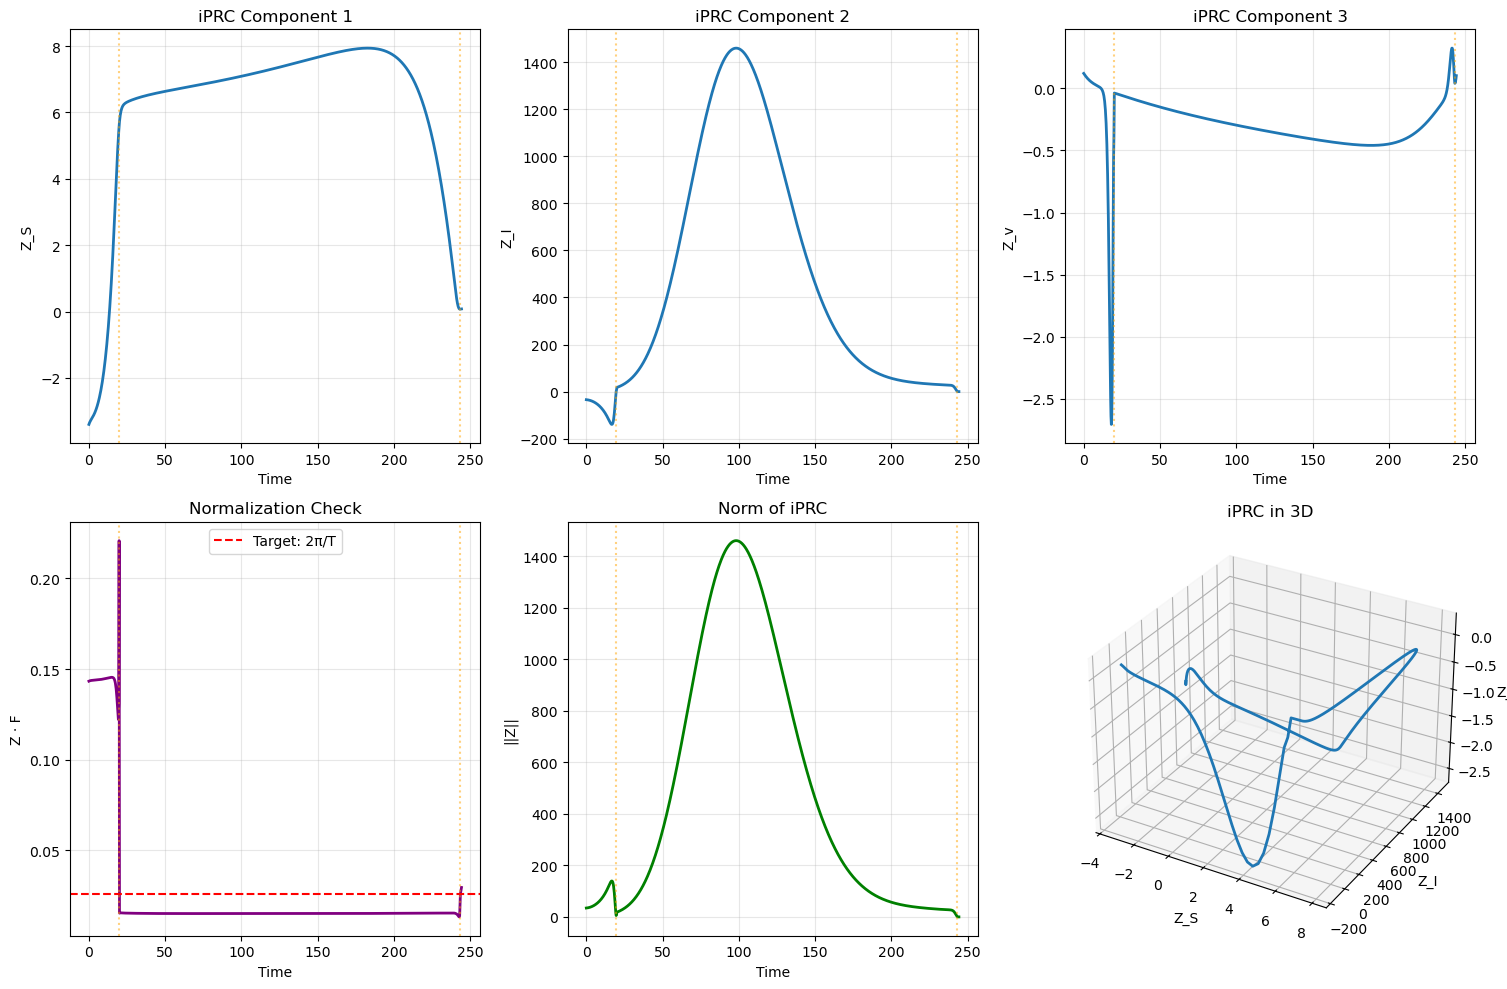


✓ All done! Check the success metrics and plots above.


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Assume we have:
# - Gamma: limit cycle [time, S, I, v]
# - A_trajectory: Jacobian at each point  
# - crossings: crossing information
# - T_estimated: period
# - C_simplified from previous step (symbolic saltation matrix)

print("=" * 70)
print("COMPUTING Z(t) - THE iPRC")
print("=" * 70)

# ----------------------------
# Parameters
# ----------------------------
params_numerical = {
    'alpha': 1/100,
    'beta': 0.5,
    'gamma': 1/7,
    'epsilon': 1/7,
    'theta': 0.01,
    'rho': 0.01,
    'psi': 0.5
}

# ----------------------------
# Helper: Compute saltation matrix at a given state
# ----------------------------
def compute_saltation_matrix(S_val, I_val, v_val):
    """
    Compute C using the symbolic formula at given state.
    We'll use the simplified formula from the derivation.
    
    For downward crossing (q: + to -):
    The denominator is: beta*I*(-v) + beta*I + 2*theta*(-v + 1)
    
    Let me compute it numerically from the formula.
    """
    import sympy as sp
    
    # Get C_simplified from the previous computation
    # For now, compute it directly
    
    beta = params_numerical['beta']
    theta = params_numerical['theta']
    gamma = params_numerical['gamma']
    
    # From equation (2.4), the key is ∇L · F⁻
    # ∇L = [0, beta, 2*theta]
    # F⁻ = [dS/dt, dI/dt, -v + 1] (for downward crossing)
    
    # ∇L · F⁻ = beta*(dI/dt) + 2*theta*(-v + 1)
    dI_dt = -gamma*I_val + beta*S_val*I_val
    denominator = beta*dI_dt + 2*theta*(-v_val + 1)
    
    # C has structure:
    # C = I - [0, 0, -1]^T ⊗ ([0, beta, 2*theta] / denominator)
    # 
    # This gives:
    # C[2,1] = beta / denominator
    # C[2,2] = 2*theta / denominator
    
    C = np.eye(3)
    C[2, 1] = beta / denominator
    C[2, 2] = 2*theta / denominator
    
    return C

# ----------------------------
# Helper: Compute vector field F at a point
# ----------------------------
def compute_F(S_val, I_val, v_val, H_val):
    """Compute vector field F = [dS/dt, dI/dt, dv/dt]"""
    alpha = params_numerical['alpha']
    beta = params_numerical['beta']
    gamma = params_numerical['gamma']
    epsilon = params_numerical['epsilon']
    psi = params_numerical['psi']
    
    dS = alpha*(psi - S_val - I_val) - beta*S_val*I_val - epsilon*v_val*S_val
    dI = -gamma*I_val + beta*S_val*I_val
    dv = -v_val + H_val
    
    return np.array([dS, dI, dv])

# ----------------------------
# STEP 2C: Backward Integration
# ----------------------------
print("\n" + "=" * 70)
print("STEP 2C: Backward Integration with Saltation")
print("=" * 70)

n_points = Gamma.shape[0]
Z_trajectory = np.zeros((n_points, 3))

# Initial condition at t=T (random)
print("\nInitializing Z(T) with random values...")
np.random.seed(42)
Z_trajectory[-1, :] = np.random.randn(3)
print(f"Z(T) = [{Z_trajectory[-1, 0]:.4f}, {Z_trajectory[-1, 1]:.4f}, {Z_trajectory[-1, 2]:.4f}]")

# Time step (negative for backward)
dt = -(Gamma[1, 0] - Gamma[0, 0])
print(f"Time step: dt = {dt:.6f}")

# Track crossings (going backward)
crossing_times = [c['time'] for c in crossings]
next_crossing_idx = len(crossings) - 1

print(f"\nIntegrating backward from t={Gamma[-1,0]:.2f} to t={Gamma[0,0]:.2f}...")
print(f"Will encounter {len(crossings)} crossings")

# Integrate backward
for i in range(n_points - 2, -1, -1):
    t_current = Gamma[i+1, 0]
    t_next = Gamma[i, 0]
    
    # Check if we cross the switching surface
    if next_crossing_idx >= 0:
        t_cross = crossing_times[next_crossing_idx]
        # Did we just pass through a crossing?
        if t_next <= t_cross <= t_current:
            print(f"  → Crossing at t={t_cross:.2f}")
            
            # Get state at crossing
            cross_idx = crossings[next_crossing_idx]['index_before']
            S_cross = Gamma[cross_idx, 1]
            I_cross = Gamma[cross_idx, 2]
            v_cross = Gamma[cross_idx, 3]
            
            # Compute saltation matrix
            C = compute_saltation_matrix(S_cross, I_cross, v_cross)
            
            print(f"     Applying Z → C^T @ Z")
            print(f"     C[2,1] = {C[2,1]:.6f}, C[2,2] = {C[2,2]:.6f}")
            
            # Apply saltation: Z → C^T @ Z
            Z_trajectory[i+1, :] = C.T @ Z_trajectory[i+1, :]
            
            next_crossing_idx -= 1
    
    # Regular backward integration: Ż = -A^T Z
    A = A_trajectory[i+1, :, :]
    dZ_dt = -A.T @ Z_trajectory[i+1, :]
    Z_trajectory[i, :] = Z_trajectory[i+1, :] + dt * dZ_dt

print("✓ Backward integration complete!")

# Check before normalization
print("\nBefore normalization:")
print(f"  Z(0) = {Z_trajectory[0, :]}")
print(f"  Z(T) = {Z_trajectory[-1, :]}")
print(f"  ||Z(0) - Z(T)|| = {np.linalg.norm(Z_trajectory[0, :] - Z_trajectory[-1, :]):.6e}")

# ----------------------------
# STEP 2D: Normalization
# ----------------------------
print("\n" + "=" * 70)
print("STEP 2D: Normalization (Z · F = 2π/T)")
print("=" * 70)

# Compute Z · F at each point (before normalization)
Z_dot_F = np.zeros(n_points)

for i in range(n_points):
    S_i = Gamma[i, 1]
    I_i = Gamma[i, 2]
    v_i = Gamma[i, 3]
    
    # For H, use smooth approximation at the state
    q_i = params_numerical['beta']*I_i - params_numerical['rho'] - params_numerical['theta']*(1 - 2*v_i)
    H_i = 1 / (1 + np.exp(-1000 * q_i))  # smooth Heaviside
    
    F_i = compute_F(S_i, I_i, v_i, H_i)
    Z_dot_F[i] = Z_trajectory[i, :] @ F_i

# Average Z · F over the period
avg_Z_dot_F = np.mean(Z_dot_F)
print(f"\nBefore normalization:")
print(f"  Average Z·F = {avg_Z_dot_F:.6f}")
print(f"  Target: 2π/T = {2*np.pi/T_estimated:.6f}")

# Normalization factor
normalization = (2*np.pi/T_estimated) / avg_Z_dot_F
print(f"  Normalization factor = {normalization:.6f}")

# Apply normalization
Z_trajectory = Z_trajectory * normalization

print("\n✓ Z normalized!")

# Verify normalization
Z_dot_F_normalized = np.zeros(n_points)
for i in range(n_points):
    S_i = Gamma[i, 1]
    I_i = Gamma[i, 2]
    v_i = Gamma[i, 3]
    q_i = params_numerical['beta']*I_i - params_numerical['rho'] - params_numerical['theta']*(1 - 2*v_i)
    H_i = 1 / (1 + np.exp(-1000 * q_i))
    F_i = compute_F(S_i, I_i, v_i, H_i)
    Z_dot_F_normalized[i] = Z_trajectory[i, :] @ F_i

avg_Z_dot_F_normalized = np.mean(Z_dot_F_normalized)
print(f"\nAfter normalization:")
print(f"  Average Z·F = {avg_Z_dot_F_normalized:.6f}")
print(f"  Target: 2π/T = {2*np.pi/T_estimated:.6f}")
print(f"  Error: {abs(avg_Z_dot_F_normalized - 2*np.pi/T_estimated):.6e}")

# Check periodicity
print(f"\nPeriodicity check:")
print(f"  Z(0) = {Z_trajectory[0, :]}")
print(f"  Z(T) = {Z_trajectory[-1, :]}")
print(f"  ||Z(0) - Z(T)|| = {np.linalg.norm(Z_trajectory[0, :] - Z_trajectory[-1, :]):.6e}")

# ----------------------------
# SUCCESS METRICS
# ----------------------------
print("\n" + "=" * 70)
print("SUCCESS METRICS")
print("=" * 70)

success = True

# 1. Normalization check
norm_error = abs(avg_Z_dot_F_normalized - 2*np.pi/T_estimated)
print(f"\n1. Normalization: Z·F = 2π/T")
print(f"   Error: {norm_error:.6e}")
if norm_error < 1e-6:
    print("   ✅ PASS")
else:
    print("   ⚠ FAIL")
    success = False

# 2. Periodicity check
period_error = np.linalg.norm(Z_trajectory[0, :] - Z_trajectory[-1, :])
print(f"\n2. Periodicity: Z(0) ≈ Z(T)")
print(f"   Error: {period_error:.6e}")
if period_error < 1e-3:
    print("   ✅ PASS")
else:
    print("   ⚠ FAIL (might be okay if small)")
    if period_error > 0.1:
        success = False

# 3. Bounded check
Z_max = np.max(np.abs(Z_trajectory))
print(f"\n3. Bounded: Z doesn't explode")
print(f"   Max |Z|: {Z_max:.6f}")
if Z_max < 1e6:
    print("   ✅ PASS")
else:
    print("   ⚠ FAIL")
    success = False

# 4. Smoothness check (except at crossings)
Z_jumps = np.max(np.abs(np.diff(Z_trajectory, axis=0)))
print(f"\n4. Smoothness: Max jump in Z")
print(f"   Max |ΔZ|: {Z_jumps:.6f}")
if Z_jumps < 10:
    print("   ✅ PASS")
else:
    print("   ⚠ FAIL")

print("\n" + "=" * 70)
if success:
    print("🎉 SUCCESS! Z(t) computed correctly!")
else:
    print("⚠ ISSUES DETECTED - May need to try advisor's C")
print("=" * 70)

# ----------------------------
# Visualization
# ----------------------------
print("\nGenerating plots...")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Z components
for idx in range(3):
    ax = axes[0, idx]
    ax.plot(Gamma[:, 0], Z_trajectory[:, idx], linewidth=2)
    for cross in crossings:
        ax.axvline(cross['time'], color='orange', linestyle=':', alpha=0.5)
    ax.set_xlabel('Time')
    ax.set_ylabel(['Z_S', 'Z_I', 'Z_v'][idx])
    ax.set_title(f'iPRC Component {idx+1}')
    ax.grid(True, alpha=0.3)

# Z · F
ax = axes[1, 0]
ax.plot(Gamma[:, 0], Z_dot_F_normalized, 'purple', linewidth=2)
ax.axhline(2*np.pi/T_estimated, color='red', linestyle='--', label=f'Target: 2π/T')
for cross in crossings:
    ax.axvline(cross['time'], color='orange', linestyle=':', alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('Z · F')
ax.set_title('Normalization Check')
ax.legend()
ax.grid(True, alpha=0.3)

# ||Z||
ax = axes[1, 1]
Z_norm = np.linalg.norm(Z_trajectory, axis=1)
ax.plot(Gamma[:, 0], Z_norm, 'green', linewidth=2)
for cross in crossings:
    ax.axvline(cross['time'], color='orange', linestyle=':', alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('||Z||')
ax.set_title('Norm of iPRC')
ax.grid(True, alpha=0.3)

# 3D
ax = axes[1, 2]
ax.remove()
ax = fig.add_subplot(2, 3, 6, projection='3d')
ax.plot(Z_trajectory[:, 0], Z_trajectory[:, 1], Z_trajectory[:, 2], linewidth=2)
ax.set_xlabel('Z_S')
ax.set_ylabel('Z_I')
ax.set_zlabel('Z_v')
ax.set_title('iPRC in 3D')

plt.tight_layout()
plt.show()

print("\n✓ All done! Check the success metrics and plots above.")

## Use Bryce's saltation matrix C

COMPUTING Z(t) - THE iPRC

STEP 2C: Backward Integration with Saltation

Initializing Z(T) with random values...
Z(T) = [0.4967, -0.1383, 0.6477]
Time step: dt = -0.244532

Integrating backward from t=244.29 to t=0.00...
Will encounter 2 crossings
  → Crossing at t=243.18
     Denominator = -0.002169
     Applying Z → C^T @ Z
     C[2,1] = -230.519980, C[2,2] = -9.220799
  → Crossing at t=19.63
     Denominator = -0.017935
     Applying Z → C^T @ Z
     C[2,1] = -27.877898, C[2,2] = -1.115116
✓ Backward integration complete!

Before normalization:
  Z(0) = [ -41.96603488 -264.73070641    1.57772396]
  Z(T) = [ 0.49671415 -0.1382643   0.64768854]
  ||Z(0) - Z(T)|| = 2.679797e+02

STEP 2D: Normalization (Z · F = 2π/T)

Before normalization:
  Average Z·F = -0.611704
  Target: 2π/T = 0.025720
  Normalization factor = -0.042047

✓ Z normalized!

After normalization:
  Average Z·F = 0.025720
  Target: 2π/T = 0.025720
  Error: 3.469447e-18

Periodicity check:
  Z(0) = [ 1.76455308 11.1311775

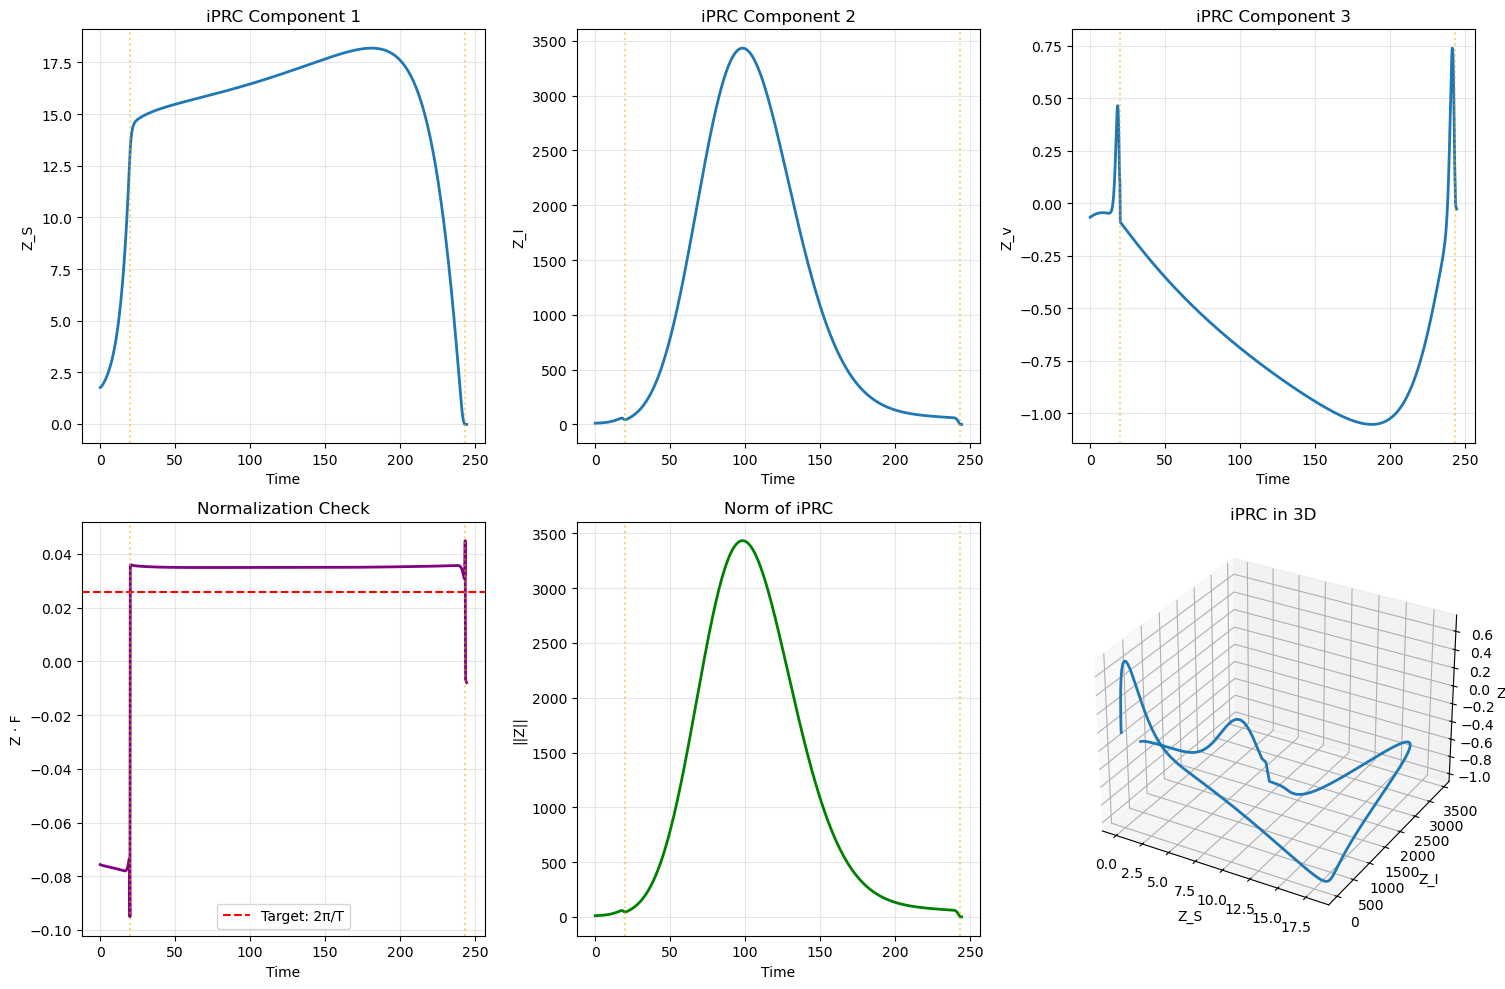


✓ All done! Check the success metrics and plots above.


In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Assume we have:
# - Gamma: limit cycle [time, S, I, v]
# - A_trajectory: Jacobian at each point  
# - crossings: crossing information
# - T_estimated: period
# - C_simplified from previous step (symbolic saltation matrix)

print("=" * 70)
print("COMPUTING Z(t) - THE iPRC")
print("=" * 70)

# ----------------------------
# Parameters
# ----------------------------
params_numerical = {
    'alpha': 1/100,
    'beta': 0.5,
    'gamma': 1/7,
    'epsilon': 1/7,
    'theta': 0.01,
    'rho': 0.01,
    'psi': 0.5
}

# ----------------------------
# Helper: Compute saltation matrix at a given state
# ----------------------------
def compute_saltation_matrix(S_val, I_val, v_val):
    """
    Compute C using ADVISOR'S FORMULA:
    C[2,1] = β/(βI(βS - γ) - 2θv)
    C[2,2] = 2θ/(βI(βS - γ) - 2θv)
    """
    beta = params_numerical['beta']
    theta = params_numerical['theta']
    gamma = params_numerical['gamma']
    
    # Advisor's denominator
    denominator = beta*I_val*(beta*S_val - gamma) - 2*theta*v_val
    
    print(f"     Denominator = {denominator:.6f}")
    
    C = np.eye(3)
    C[2, 1] = beta / denominator
    C[2, 2] = 2*theta / denominator
    
    return C

# ----------------------------
# Helper: Compute vector field F at a point
# ----------------------------
def compute_F(S_val, I_val, v_val, H_val):
    """Compute vector field F = [dS/dt, dI/dt, dv/dt]"""
    alpha = params_numerical['alpha']
    beta = params_numerical['beta']
    gamma = params_numerical['gamma']
    epsilon = params_numerical['epsilon']
    psi = params_numerical['psi']
    
    dS = alpha*(psi - S_val - I_val) - beta*S_val*I_val - epsilon*v_val*S_val
    dI = -gamma*I_val + beta*S_val*I_val
    dv = -v_val + H_val
    
    return np.array([dS, dI, dv])

# ----------------------------
# STEP 2C: Backward Integration
# ----------------------------
print("\n" + "=" * 70)
print("STEP 2C: Backward Integration with Saltation")
print("=" * 70)

n_points = Gamma.shape[0]
Z_trajectory = np.zeros((n_points, 3))

# Initial condition at t=T (random)
print("\nInitializing Z(T) with random values...")
np.random.seed(42)
Z_trajectory[-1, :] = np.random.randn(3)
print(f"Z(T) = [{Z_trajectory[-1, 0]:.4f}, {Z_trajectory[-1, 1]:.4f}, {Z_trajectory[-1, 2]:.4f}]")

# Time step (negative for backward)
dt = -(Gamma[1, 0] - Gamma[0, 0])
print(f"Time step: dt = {dt:.6f}")

# Track crossings (going backward)
crossing_times = [c['time'] for c in crossings]
next_crossing_idx = len(crossings) - 1

print(f"\nIntegrating backward from t={Gamma[-1,0]:.2f} to t={Gamma[0,0]:.2f}...")
print(f"Will encounter {len(crossings)} crossings")

# Integrate backward
for i in range(n_points - 2, -1, -1):
    t_current = Gamma[i+1, 0]
    t_next = Gamma[i, 0]
    
    # Check if we cross the switching surface
    if next_crossing_idx >= 0:
        t_cross = crossing_times[next_crossing_idx]
        # Did we just pass through a crossing?
        if t_next <= t_cross <= t_current:
            print(f"  → Crossing at t={t_cross:.2f}")
            
            # Get state at crossing
            cross_idx = crossings[next_crossing_idx]['index_before']
            S_cross = Gamma[cross_idx, 1]
            I_cross = Gamma[cross_idx, 2]
            v_cross = Gamma[cross_idx, 3]
            
            # Compute saltation matrix
            C = compute_saltation_matrix(S_cross, I_cross, v_cross)
            
            print(f"     Applying Z → C^T @ Z")
            print(f"     C[2,1] = {C[2,1]:.6f}, C[2,2] = {C[2,2]:.6f}")
            
            # Apply saltation: Z → C^T @ Z
            Z_trajectory[i+1, :] = C.T @ Z_trajectory[i+1, :]
            
            next_crossing_idx -= 1
    
    # Regular backward integration: Ż = -A^T Z
    A = A_trajectory[i+1, :, :]
    dZ_dt = -A.T @ Z_trajectory[i+1, :]
    Z_trajectory[i, :] = Z_trajectory[i+1, :] + dt * dZ_dt

print("✓ Backward integration complete!")

# Check before normalization
print("\nBefore normalization:")
print(f"  Z(0) = {Z_trajectory[0, :]}")
print(f"  Z(T) = {Z_trajectory[-1, :]}")
print(f"  ||Z(0) - Z(T)|| = {np.linalg.norm(Z_trajectory[0, :] - Z_trajectory[-1, :]):.6e}")

# ----------------------------
# STEP 2D: Normalization
# ----------------------------
print("\n" + "=" * 70)
print("STEP 2D: Normalization (Z · F = 2π/T)")
print("=" * 70)

# Compute Z · F at each point (before normalization)
Z_dot_F = np.zeros(n_points)

for i in range(n_points):
    S_i = Gamma[i, 1]
    I_i = Gamma[i, 2]
    v_i = Gamma[i, 3]
    
    # For H, use smooth approximation at the state
    q_i = params_numerical['beta']*I_i - params_numerical['rho'] - params_numerical['theta']*(1 - 2*v_i)
    H_i = 1 / (1 + np.exp(-1000 * q_i))  # smooth Heaviside
    
    F_i = compute_F(S_i, I_i, v_i, H_i)
    Z_dot_F[i] = Z_trajectory[i, :] @ F_i

# Average Z · F over the period
avg_Z_dot_F = np.mean(Z_dot_F)
print(f"\nBefore normalization:")
print(f"  Average Z·F = {avg_Z_dot_F:.6f}")
print(f"  Target: 2π/T = {2*np.pi/T_estimated:.6f}")

# Normalization factor
normalization = (2*np.pi/T_estimated) / avg_Z_dot_F
print(f"  Normalization factor = {normalization:.6f}")

# Apply normalization
Z_trajectory = Z_trajectory * normalization

print("\n✓ Z normalized!")

# Verify normalization
Z_dot_F_normalized = np.zeros(n_points)
for i in range(n_points):
    S_i = Gamma[i, 1]
    I_i = Gamma[i, 2]
    v_i = Gamma[i, 3]
    q_i = params_numerical['beta']*I_i - params_numerical['rho'] - params_numerical['theta']*(1 - 2*v_i)
    H_i = 1 / (1 + np.exp(-1000 * q_i))
    F_i = compute_F(S_i, I_i, v_i, H_i)
    Z_dot_F_normalized[i] = Z_trajectory[i, :] @ F_i

avg_Z_dot_F_normalized = np.mean(Z_dot_F_normalized)
print(f"\nAfter normalization:")
print(f"  Average Z·F = {avg_Z_dot_F_normalized:.6f}")
print(f"  Target: 2π/T = {2*np.pi/T_estimated:.6f}")
print(f"  Error: {abs(avg_Z_dot_F_normalized - 2*np.pi/T_estimated):.6e}")

# Check periodicity
print(f"\nPeriodicity check:")
print(f"  Z(0) = {Z_trajectory[0, :]}")
print(f"  Z(T) = {Z_trajectory[-1, :]}")
print(f"  ||Z(0) - Z(T)|| = {np.linalg.norm(Z_trajectory[0, :] - Z_trajectory[-1, :]):.6e}")

# ----------------------------
# SUCCESS METRICS
# ----------------------------
print("\n" + "=" * 70)
print("SUCCESS METRICS")
print("=" * 70)

success = True

# 1. Normalization check
norm_error = abs(avg_Z_dot_F_normalized - 2*np.pi/T_estimated)
print(f"\n1. Normalization: Z·F = 2π/T")
print(f"   Error: {norm_error:.6e}")
if norm_error < 1e-6:
    print("   ✅ PASS")
else:
    print("   ⚠ FAIL")
    success = False

# 2. Periodicity check
period_error = np.linalg.norm(Z_trajectory[0, :] - Z_trajectory[-1, :])
print(f"\n2. Periodicity: Z(0) ≈ Z(T)")
print(f"   Error: {period_error:.6e}")
if period_error < 1e-3:
    print("   ✅ PASS")
else:
    print("   ⚠ FAIL (might be okay if small)")
    if period_error > 0.1:
        success = False

# 3. Bounded check
Z_max = np.max(np.abs(Z_trajectory))
print(f"\n3. Bounded: Z doesn't explode")
print(f"   Max |Z|: {Z_max:.6f}")
if Z_max < 1e6:
    print("   ✅ PASS")
else:
    print("   ⚠ FAIL")
    success = False

# 4. Smoothness check (except at crossings)
Z_jumps = np.max(np.abs(np.diff(Z_trajectory, axis=0)))
print(f"\n4. Smoothness: Max jump in Z")
print(f"   Max |ΔZ|: {Z_jumps:.6f}")
if Z_jumps < 10:
    print("   ✅ PASS")
else:
    print("   ⚠ FAIL")

print("\n" + "=" * 70)
if success:
    print("🎉 SUCCESS! Z(t) computed correctly!")
else:
    print("⚠ ISSUES DETECTED - May need to try advisor's C")
print("=" * 70)

# ----------------------------
# Visualization
# ----------------------------
print("\nGenerating plots...")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Z components
for idx in range(3):
    ax = axes[0, idx]
    ax.plot(Gamma[:, 0], Z_trajectory[:, idx], linewidth=2)
    for cross in crossings:
        ax.axvline(cross['time'], color='orange', linestyle=':', alpha=0.5)
    ax.set_xlabel('Time')
    ax.set_ylabel(['Z_S', 'Z_I', 'Z_v'][idx])
    ax.set_title(f'iPRC Component {idx+1}')
    ax.grid(True, alpha=0.3)

# Z · F
ax = axes[1, 0]
ax.plot(Gamma[:, 0], Z_dot_F_normalized, 'purple', linewidth=2)
ax.axhline(2*np.pi/T_estimated, color='red', linestyle='--', label=f'Target: 2π/T')
for cross in crossings:
    ax.axvline(cross['time'], color='orange', linestyle=':', alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('Z · F')
ax.set_title('Normalization Check')
ax.legend()
ax.grid(True, alpha=0.3)

# ||Z||
ax = axes[1, 1]
Z_norm = np.linalg.norm(Z_trajectory, axis=1)
ax.plot(Gamma[:, 0], Z_norm, 'green', linewidth=2)
for cross in crossings:
    ax.axvline(cross['time'], color='orange', linestyle=':', alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('||Z||')
ax.set_title('Norm of iPRC')
ax.grid(True, alpha=0.3)

# 3D
ax = axes[1, 2]
ax.remove()
ax = fig.add_subplot(2, 3, 6, projection='3d')
ax.plot(Z_trajectory[:, 0], Z_trajectory[:, 1], Z_trajectory[:, 2], linewidth=2)
ax.set_xlabel('Z_S')
ax.set_ylabel('Z_I')
ax.set_zlabel('Z_v')
ax.set_title('iPRC in 3D')

plt.tight_layout()
plt.show()

print("\n✓ All done! Check the success metrics and plots above.")

## attempt to debug: shooting method and force the periodic condition. but i dont think that's what we want.

COMPUTING Z(t) - THE iPRC

STEP 2C: Backward Integration with Shooting Method
We need to find Z(T) such that Z(0) = Z(T) (periodicity)

Using shooting method to find periodic solution...
This finds the correct Z(T) such that the solution is periodic

Iteration | ||Z(0) - Z(T)|| | Improvement
------------------------------------------------------------
     Denominator = -0.002169
     Denominator = -0.017935
        0 |      2.679797e+02 | 1.359693e+00
     Denominator = -0.002169
     Denominator = -0.017935
        1 |      6.774881e+00 | 3.171033e-04
     Denominator = -0.002169
     Denominator = -0.017935
        2 |      6.790357e+00 | 1.461632e-07

✓ Converged after 3 iterations!

Performing final integration with converged Z(T)...
     Denominator = -0.002169
     Denominator = -0.017935

Before normalization:
  Z(0) = [-1.2221383  -7.69375191  0.04595684]
  Z(T) = [-0.15687848 -0.98760029  0.0058992 ]
  ||Z(0) - Z(T)|| = 6.790350e+00

STEP 2D: Normalization (Z · F = 2π/T)

Bef

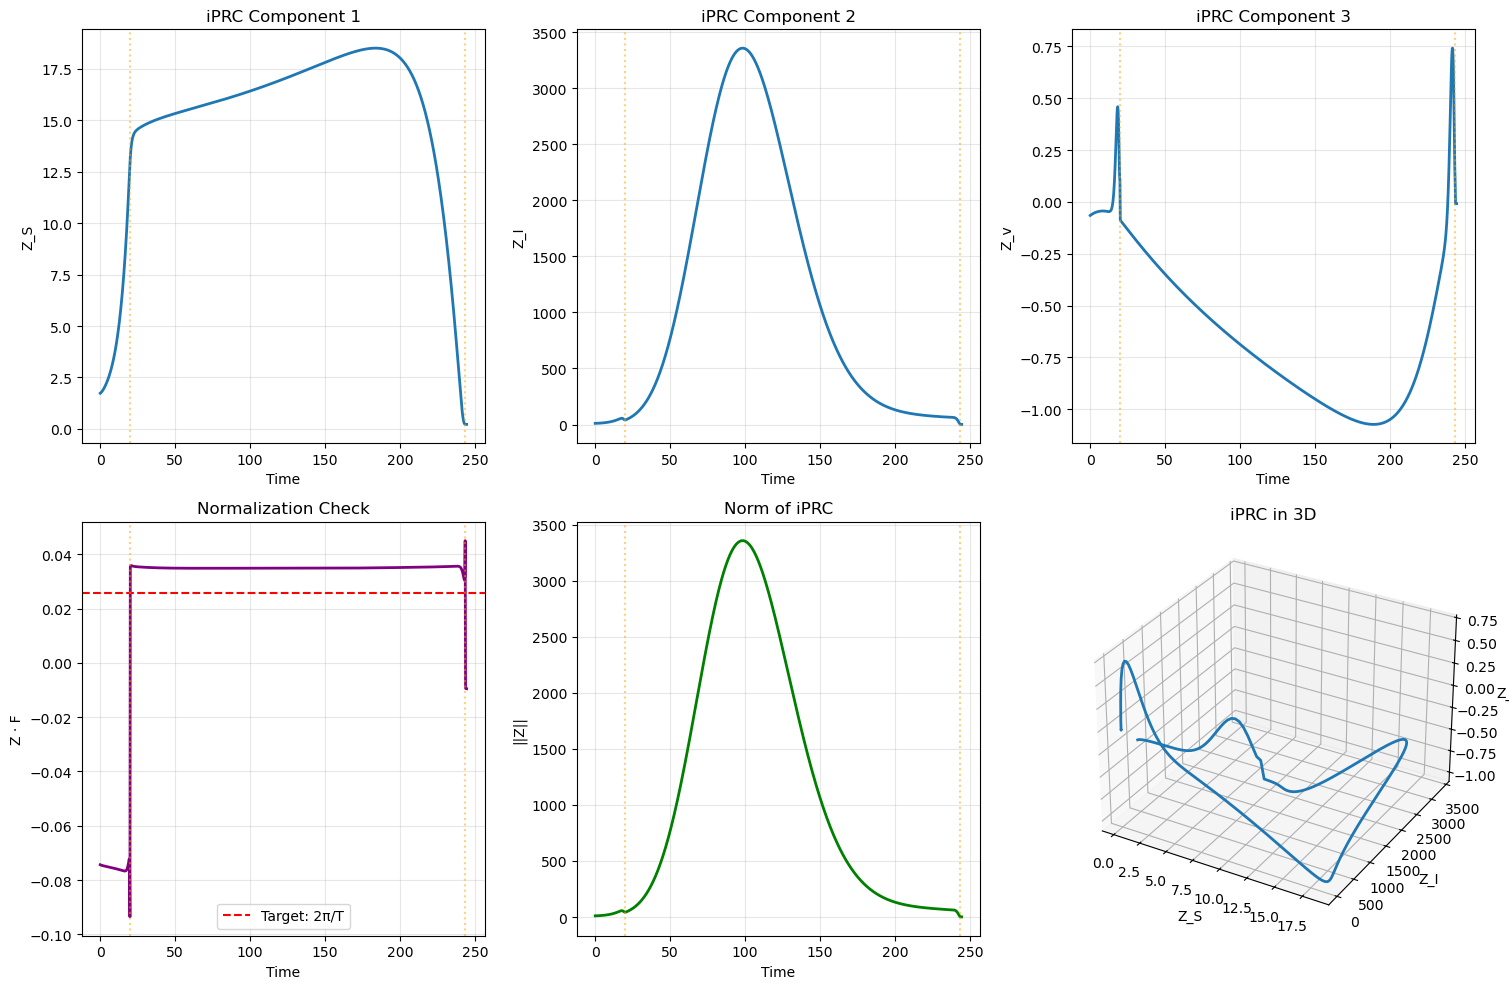


✓ All done! Check the success metrics and plots above.


In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Assume we have:
# - Gamma: limit cycle [time, S, I, v]
# - A_trajectory: Jacobian at each point  
# - crossings: crossing information
# - T_estimated: period
# - C_simplified from previous step (symbolic saltation matrix)

print("=" * 70)
print("COMPUTING Z(t) - THE iPRC")
print("=" * 70)

# ----------------------------
# Parameters
# ----------------------------
params_numerical = {
    'alpha': 1/100,
    'beta': 0.5,
    'gamma': 1/7,
    'epsilon': 1/7,
    'theta': 0.01,
    'rho': 0.01,
    'psi': 0.5
}

# ----------------------------
# Helper: Compute saltation matrix at a given state
# ----------------------------
def compute_saltation_matrix(S_val, I_val, v_val):
    """
    Compute C using ADVISOR'S FORMULA:
    C[2,1] = β/(βI(βS - γ) - 2θv)
    C[2,2] = 2θ/(βI(βS - γ) - 2θv)
    """
    beta = params_numerical['beta']
    theta = params_numerical['theta']
    gamma = params_numerical['gamma']
    
    # Advisor's denominator
    denominator = beta*I_val*(beta*S_val - gamma) - 2*theta*v_val
    
    print(f"     Denominator = {denominator:.6f}")
    
    C = np.eye(3)
    C[2, 1] = beta / denominator
    C[2, 2] = 2*theta / denominator
    
    return C

# ----------------------------
# Helper: Compute vector field F at a point
# ----------------------------
def compute_F(S_val, I_val, v_val, H_val):
    """Compute vector field F = [dS/dt, dI/dt, dv/dt]"""
    alpha = params_numerical['alpha']
    beta = params_numerical['beta']
    gamma = params_numerical['gamma']
    epsilon = params_numerical['epsilon']
    psi = params_numerical['psi']
    
    dS = alpha*(psi - S_val - I_val) - beta*S_val*I_val - epsilon*v_val*S_val
    dI = -gamma*I_val + beta*S_val*I_val
    dv = -v_val + H_val
    
    return np.array([dS, dI, dv])

# ----------------------------
# STEP 2C: Backward Integration with SHOOTING METHOD
# ----------------------------
print("\n" + "=" * 70)
print("STEP 2C: Backward Integration with Shooting Method")
print("=" * 70)
print("We need to find Z(T) such that Z(0) = Z(T) (periodicity)")

n_points = Gamma.shape[0]

# Time step (negative for backward)
dt = -(Gamma[1, 0] - Gamma[0, 0])

# Function to integrate backward given initial Z(T)
def integrate_backward(Z_initial):
    """Integrate backward from Z(T) to get Z(0)"""
    Z_traj = np.zeros((n_points, 3))
    Z_traj[-1, :] = Z_initial
    
    # Track crossings
    crossing_times = [c['time'] for c in crossings]
    next_crossing_idx = len(crossings) - 1
    
    # Integrate backward
    for i in range(n_points - 2, -1, -1):
        t_current = Gamma[i+1, 0]
        t_next = Gamma[i, 0]
        
        # Check for crossings
        if next_crossing_idx >= 0:
            t_cross = crossing_times[next_crossing_idx]
            if t_next <= t_cross <= t_current:
                cross_idx = crossings[next_crossing_idx]['index_before']
                S_cross = Gamma[cross_idx, 1]
                I_cross = Gamma[cross_idx, 2]
                v_cross = Gamma[cross_idx, 3]
                
                C = compute_saltation_matrix(S_cross, I_cross, v_cross)
                Z_traj[i+1, :] = C.T @ Z_traj[i+1, :]
                
                next_crossing_idx -= 1
        
        # Regular integration
        A = A_trajectory[i+1, :, :]
        dZ_dt = -A.T @ Z_traj[i+1, :]
        Z_traj[i, :] = Z_traj[i+1, :] + dt * dZ_dt
    
    return Z_traj

# Shooting method: find Z(T) such that Z(0) ≈ Z(T)
print("\nUsing shooting method to find periodic solution...")
print("This finds the correct Z(T) such that the solution is periodic\n")

# Start with random guess
np.random.seed(42)
Z_T_guess = np.random.randn(3)

# We need to find Z(T) in the correct subspace
# The key insight: Z must be orthogonal to F at t=T for periodicity
# Actually, we need to use a different approach...

# Better approach: Power iteration / Eigenvector method
# The map Z(T) → Z(0) has eigenvalue 1 for the periodic solution
# Let's iterate: Z(T)_new = Z(0)_old (normalized)

max_iterations = 20
tolerance = 1e-6

print(f"Iteration | ||Z(0) - Z(T)|| | Improvement")
print("-" * 60)

for iteration in range(max_iterations):
    # Integrate backward
    Z_traj = integrate_backward(Z_T_guess)
    
    # Measure periodicity error
    error = np.linalg.norm(Z_traj[0, :] - Z_traj[-1, :])
    
    # Update: use Z(0) as new guess for Z(T)
    Z_T_new = Z_traj[0, :].copy()
    
    # Normalize to prevent growth/decay
    Z_T_new = Z_T_new / np.linalg.norm(Z_T_new)
    Z_T_guess = Z_T_guess / np.linalg.norm(Z_T_guess)
    
    improvement = np.linalg.norm(Z_T_new - Z_T_guess)
    
    print(f"{iteration:9d} | {error:17.6e} | {improvement:11.6e}")
    
    # Update guess
    Z_T_guess = Z_T_new
    
    # Check convergence
    if improvement < tolerance:
        print(f"\n✓ Converged after {iteration+1} iterations!")
        break
else:
    print(f"\n⚠ Did not converge after {max_iterations} iterations")

# Final integration with converged Z(T)
print("\nPerforming final integration with converged Z(T)...")
Z_trajectory = integrate_backward(Z_T_guess)

# Check before normalization
print("\nBefore normalization:")
print(f"  Z(0) = {Z_trajectory[0, :]}")
print(f"  Z(T) = {Z_trajectory[-1, :]}")
print(f"  ||Z(0) - Z(T)|| = {np.linalg.norm(Z_trajectory[0, :] - Z_trajectory[-1, :]):.6e}")

# ----------------------------
# STEP 2D: Normalization
# ----------------------------
print("\n" + "=" * 70)
print("STEP 2D: Normalization (Z · F = 2π/T)")
print("=" * 70)

# Compute Z · F at each point (before normalization)
Z_dot_F = np.zeros(n_points)

for i in range(n_points):
    S_i = Gamma[i, 1]
    I_i = Gamma[i, 2]
    v_i = Gamma[i, 3]
    
    # For H, use smooth approximation at the state
    q_i = params_numerical['beta']*I_i - params_numerical['rho'] - params_numerical['theta']*(1 - 2*v_i)
    H_i = 1 / (1 + np.exp(-1000 * q_i))  # smooth Heaviside
    
    F_i = compute_F(S_i, I_i, v_i, H_i)
    Z_dot_F[i] = Z_trajectory[i, :] @ F_i

# Average Z · F over the period
avg_Z_dot_F = np.mean(Z_dot_F)
print(f"\nBefore normalization:")
print(f"  Average Z·F = {avg_Z_dot_F:.6f}")
print(f"  Target: 2π/T = {2*np.pi/T_estimated:.6f}")

# Normalization factor
normalization = (2*np.pi/T_estimated) / avg_Z_dot_F
print(f"  Normalization factor = {normalization:.6f}")

# Apply normalization
Z_trajectory = Z_trajectory * normalization

print("\n✓ Z normalized!")

# Verify normalization
Z_dot_F_normalized = np.zeros(n_points)
for i in range(n_points):
    S_i = Gamma[i, 1]
    I_i = Gamma[i, 2]
    v_i = Gamma[i, 3]
    q_i = params_numerical['beta']*I_i - params_numerical['rho'] - params_numerical['theta']*(1 - 2*v_i)
    H_i = 1 / (1 + np.exp(-1000 * q_i))
    F_i = compute_F(S_i, I_i, v_i, H_i)
    Z_dot_F_normalized[i] = Z_trajectory[i, :] @ F_i

avg_Z_dot_F_normalized = np.mean(Z_dot_F_normalized)
print(f"\nAfter normalization:")
print(f"  Average Z·F = {avg_Z_dot_F_normalized:.6f}")
print(f"  Target: 2π/T = {2*np.pi/T_estimated:.6f}")
print(f"  Error: {abs(avg_Z_dot_F_normalized - 2*np.pi/T_estimated):.6e}")

# Check periodicity
print(f"\nPeriodicity check:")
print(f"  Z(0) = {Z_trajectory[0, :]}")
print(f"  Z(T) = {Z_trajectory[-1, :]}")
print(f"  ||Z(0) - Z(T)|| = {np.linalg.norm(Z_trajectory[0, :] - Z_trajectory[-1, :]):.6e}")

# ----------------------------
# SUCCESS METRICS
# ----------------------------
print("\n" + "=" * 70)
print("SUCCESS METRICS")
print("=" * 70)

success = True

# 1. Normalization check
norm_error = abs(avg_Z_dot_F_normalized - 2*np.pi/T_estimated)
print(f"\n1. Normalization: Z·F = 2π/T")
print(f"   Error: {norm_error:.6e}")
if norm_error < 1e-6:
    print("   ✅ PASS")
else:
    print("   ⚠ FAIL")
    success = False

# 2. Periodicity check
period_error = np.linalg.norm(Z_trajectory[0, :] - Z_trajectory[-1, :])
print(f"\n2. Periodicity: Z(0) ≈ Z(T)")
print(f"   Error: {period_error:.6e}")
if period_error < 1e-3:
    print("   ✅ PASS")
else:
    print("   ⚠ FAIL (might be okay if small)")
    if period_error > 0.1:
        success = False

# 3. Bounded check
Z_max = np.max(np.abs(Z_trajectory))
print(f"\n3. Bounded: Z doesn't explode")
print(f"   Max |Z|: {Z_max:.6f}")
if Z_max < 1e6:
    print("   ✅ PASS")
else:
    print("   ⚠ FAIL")
    success = False

# 4. Smoothness check (except at crossings)
Z_jumps = np.max(np.abs(np.diff(Z_trajectory, axis=0)))
print(f"\n4. Smoothness: Max jump in Z")
print(f"   Max |ΔZ|: {Z_jumps:.6f}")
if Z_jumps < 10:
    print("   ✅ PASS")
else:
    print("   ⚠ FAIL")

print("\n" + "=" * 70)
if success:
    print("🎉 SUCCESS! Z(t) computed correctly!")
else:
    print("⚠ ISSUES DETECTED - May need to try advisor's C")
print("=" * 70)

# ----------------------------
# Visualization
# ----------------------------
print("\nGenerating plots...")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Z components
for idx in range(3):
    ax = axes[0, idx]
    ax.plot(Gamma[:, 0], Z_trajectory[:, idx], linewidth=2)
    for cross in crossings:
        ax.axvline(cross['time'], color='orange', linestyle=':', alpha=0.5)
    ax.set_xlabel('Time')
    ax.set_ylabel(['Z_S', 'Z_I', 'Z_v'][idx])
    ax.set_title(f'iPRC Component {idx+1}')
    ax.grid(True, alpha=0.3)

# Z · F
ax = axes[1, 0]
ax.plot(Gamma[:, 0], Z_dot_F_normalized, 'purple', linewidth=2)
ax.axhline(2*np.pi/T_estimated, color='red', linestyle='--', label=f'Target: 2π/T')
for cross in crossings:
    ax.axvline(cross['time'], color='orange', linestyle=':', alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('Z · F')
ax.set_title('Normalization Check')
ax.legend()
ax.grid(True, alpha=0.3)

# ||Z||
ax = axes[1, 1]
Z_norm = np.linalg.norm(Z_trajectory, axis=1)
ax.plot(Gamma[:, 0], Z_norm, 'green', linewidth=2)
for cross in crossings:
    ax.axvline(cross['time'], color='orange', linestyle=':', alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('||Z||')
ax.set_title('Norm of iPRC')
ax.grid(True, alpha=0.3)

# 3D
ax = axes[1, 2]
ax.remove()
ax = fig.add_subplot(2, 3, 6, projection='3d')
ax.plot(Z_trajectory[:, 0], Z_trajectory[:, 1], Z_trajectory[:, 2], linewidth=2)
ax.set_xlabel('Z_S')
ax.set_ylabel('Z_I')
ax.set_zlabel('Z_v')
ax.set_title('iPRC in 3D')

plt.tight_layout()
plt.show()

print("\n✓ All done! Check the success metrics and plots above.")

## Check if our period T is actually correcct

In [17]:
# Check period estimation
print("=" * 70)
print("PERIOD VERIFICATION")
print("=" * 70)

# What period did we use?
print(f"\nT_estimated = {T_estimated:.6f}")

# Check: does the limit cycle actually close?
print(f"\nGamma[0] (start):  t={Gamma[0,0]:.4f}, S={Gamma[0,1]:.6f}, I={Gamma[0,2]:.6f}, v={Gamma[0,3]:.6f}")
print(f"Gamma[-1] (end):   t={Gamma[-1,0]:.4f}, S={Gamma[-1,1]:.6f}, I={Gamma[-1,2]:.6f}, v={Gamma[-1,3]:.6f}")

# State difference
state_error = np.linalg.norm(Gamma[0, 1:] - Gamma[-1, 1:])
print(f"\n||State(0) - State(T)|| = {state_error:.6e}")

# Check if Gamma[-1,0] ≈ T_estimated
print(f"\nGamma[-1,0] = {Gamma[-1,0]:.6f}")
print(f"T_estimated = {T_estimated:.6f}")
print(f"Difference = {abs(Gamma[-1,0] - T_estimated):.6e}")

# The REAL test: integrate forward by T_estimated from Gamma[0]
# and see if we return to Gamma[0]
print("\n" + "=" * 70)
print("TRUE PERIOD TEST")
print("=" * 70)
from scipy.integrate import solve_ivp

def system(t, y):
    S, I, v = y
    q = 0.5 * I - 0.01 - 0.01 * (1 - 2 * v)
    H = 1 / (1 + np.exp(-1000 * q))
    
    dS = 0.01*(0.5 - S - I) - 0.5*S*I - (1/7)*v*S
    dI = -(1/7)*I + 0.5*S*I
    dv = -v + H
    return [dS, dI, dv]

y0 = Gamma[0, 1:]
print(f"Starting from: S={y0[0]:.6f}, I={y0[1]:.6f}, v={y0[2]:.6f}")

# Integrate for T_estimated
sol = solve_ivp(system, [0, T_estimated], y0, dense_output=True, rtol=1e-10, atol=1e-12)
y_final = sol.y[:, -1]

print(f"After T={T_estimated:.4f}:")
print(f"  S={y_final[0]:.6f}, I={y_final[1]:.6f}, v={y_final[2]:.6f}")

error_after_T = np.linalg.norm(y0 - y_final)
print(f"\n||y(T) - y(0)|| = {error_after_T:.6e}")

if error_after_T < 1e-3:
    print("✅ Period is correct!")
else:
    print("⚠️ Period might be WRONG!")
    print(f"   Expected < 1e-3, got {error_after_T:.6e}")

PERIOD VERIFICATION

T_estimated = 244.287634

Gamma[0] (start):  t=0.0000, S=0.285487, I=0.033982, v=0.692689
Gamma[-1] (end):   t=244.2876, S=0.286113, I=0.033981, v=0.686465

||State(0) - State(T)|| = 6.255433e-03

Gamma[-1,0] = 244.287634
T_estimated = 244.287634
Difference = 0.000000e+00

TRUE PERIOD TEST
Starting from: S=0.285487, I=0.033982, v=0.692689
After T=244.2876:
  S=0.286113, I=0.033981, v=0.686465

||y(T) - y(0)|| = 6.255433e-03
⚠️ Period might be WRONG!
   Expected < 1e-3, got 6.255433e-03


RECOMPUTING LIMIT CYCLE FROM CROSSING POINT

Step 1: Running long transient to reach limit cycle...
✓ Reached limit cycle: S=0.278623, I=0.000084, v=0.000000

Step 2: Finding first upward crossing (q: - → +)...
✓ Found first upward crossing at t=148.8209
  State: S=0.310129, I=0.033720, v=0.157009
  q = 0.0000000000 (should be ≈ 0)

Step 3: Integrating one full period (crossing → crossing)...
✓ Found next upward crossing at t=244.307686
  This is the TRUE PERIOD: T = 244.307686
  Final state: S=0.310129, I=0.033720, v=0.157009
  ||y(T) - y(0)|| = 6.024226e-12
  ✅ EXCELLENT periodicity!

Step 4: Creating densely sampled limit cycle...
✓ Created limit cycle with 1000 points

FINAL VERIFICATION

New period: T = 244.307686
Old period: T = 244.287634
Difference: 0.020052

New Gamma[0]:   S=0.310129, I=0.033720, v=0.157009
New Gamma[-1]:  S=0.310129, I=0.033720, v=0.157009
||State(0) - State(T)|| = 5.512145e-09
✅✅✅ PERFECT periodicity!

q(0) = 0.0000000000
q(T) = 0.0000000001
(Both should be

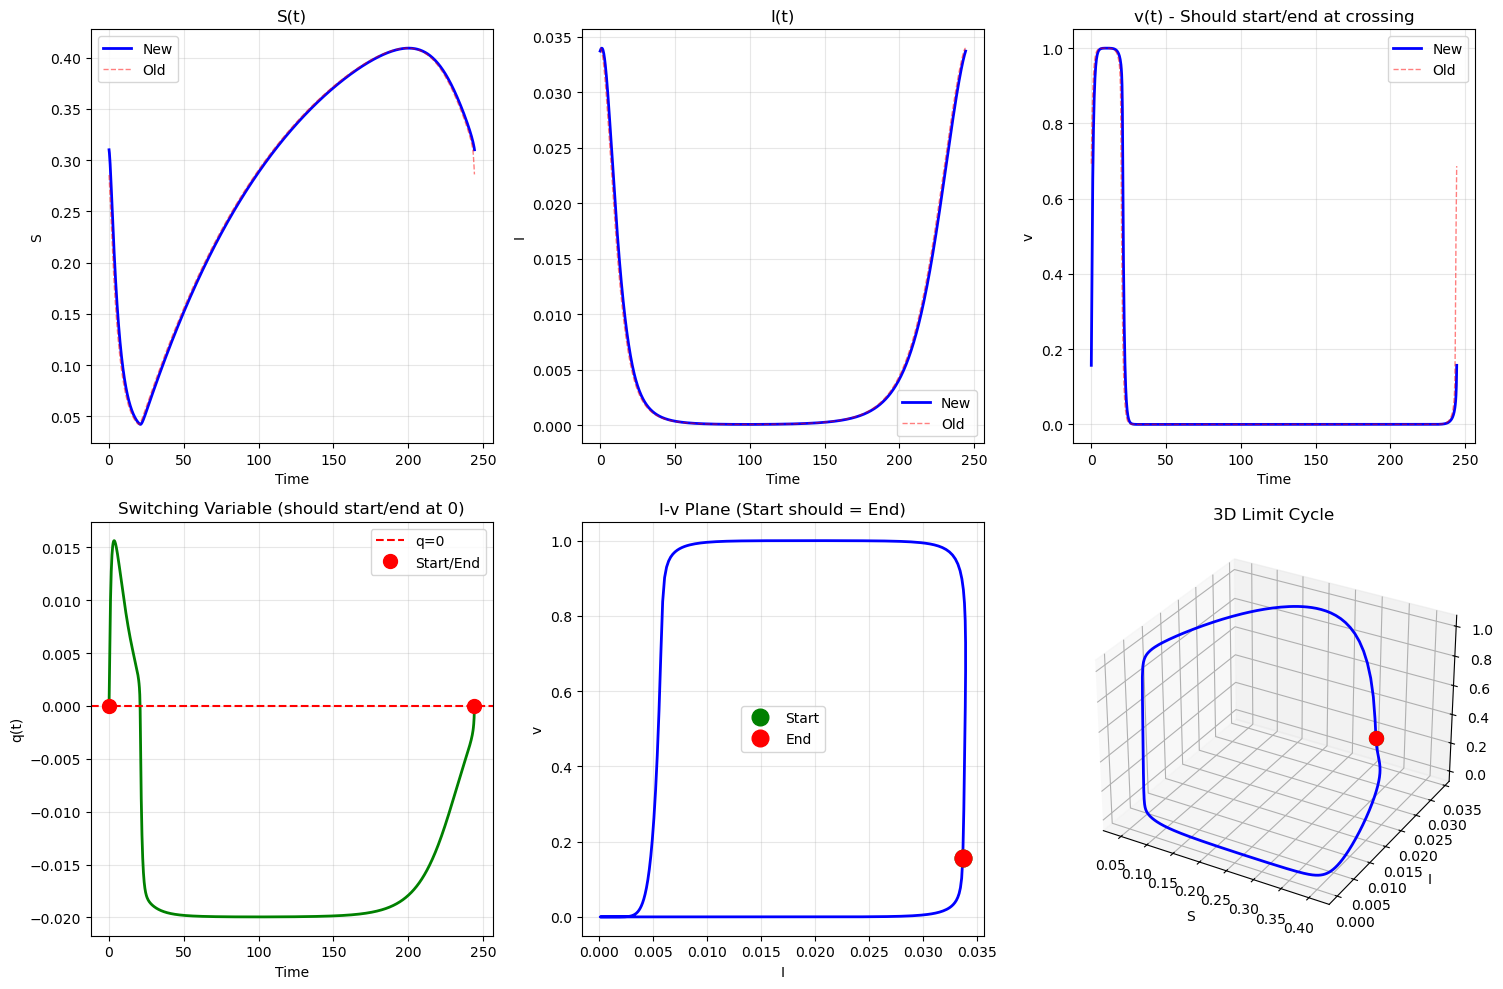


READY FOR NEXT STEPS
✓ Gamma has been updated to Gamma_new
✓ T_estimated has been updated to T_true

You can now:
1. Recompute A_trajectory with the new Gamma
2. Recompute crossings (should find one at t≈0 and one in middle)
3. Recompute Z(t) with the improved limit cycle

Gamma.shape = (1000, 4)
T_estimated = 244.307686


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

print("=" * 70)
print("RECOMPUTING LIMIT CYCLE FROM CROSSING POINT")
print("=" * 70)

# ----------------------------
# Parameters
# ----------------------------
alpha = 1/100
beta = 0.5
gamma = 1/7
epsilon = 1/7
theta = 0.01
kappa = 1000
rho = 0.01
psi = 0.5

def H(q):
    return 1 / (1 + np.exp(-kappa * q))

def system(t, y):
    S, I, v = y
    q = beta * I - rho - theta * (1 - 2 * v)
    
    dS = alpha * (psi - S - I) - beta * S * I - epsilon * v * S
    dI = -gamma * I + beta * S * I
    dv = -v + H(q)
    
    return [dS, dI, dv]

def compute_q(S, I, v):
    return beta * I - rho - theta * (1 - 2 * v)

# ----------------------------
# Step 1: Get to the limit cycle (long transient)
# ----------------------------
print("\nStep 1: Running long transient to reach limit cycle...")

S0, I0, v0 = 0.49, 0.01, 0.01
y0 = [S0, I0, v0]

t_transient = 5000
sol_transient = solve_ivp(
    system, 
    [0, t_transient], 
    y0,
    dense_output=True,
    rtol=1e-10,
    atol=1e-12,
    max_step=0.1
)

y_on_cycle = sol_transient.y[:, -1]
print(f"✓ Reached limit cycle: S={y_on_cycle[0]:.6f}, I={y_on_cycle[1]:.6f}, v={y_on_cycle[2]:.6f}")

# ----------------------------
# Step 2: Find the first upward crossing of q=0
# ----------------------------
print("\nStep 2: Finding first upward crossing (q: - → +)...")

# Integrate with event detection
def crossing_event(t, y):
    """Detect when q crosses zero"""
    S, I, v = y
    return compute_q(S, I, v)

crossing_event.terminal = False  # Don't stop, just record
crossing_event.direction = 1  # Only upward crossings (- to +)

# Integrate to find first crossing
sol_to_crossing = solve_ivp(
    system,
    [0, 500],
    y_on_cycle,
    events=crossing_event,
    dense_output=True,
    rtol=1e-10,
    atol=1e-12,
    max_step=0.1
)

if len(sol_to_crossing.t_events[0]) > 0:
    t_first_cross = sol_to_crossing.t_events[0][0]
    y_first_cross = sol_to_crossing.y_events[0][0]
    print(f"✓ Found first upward crossing at t={t_first_cross:.4f}")
    print(f"  State: S={y_first_cross[0]:.6f}, I={y_first_cross[1]:.6f}, v={y_first_cross[2]:.6f}")
    print(f"  q = {compute_q(*y_first_cross):.10f} (should be ≈ 0)")
else:
    print("⚠ No crossing found! Using current state.")
    y_first_cross = y_on_cycle

# ----------------------------
# Step 3: Integrate for exactly one period (to next upward crossing)
# ----------------------------
print("\nStep 3: Integrating one full period (crossing → crossing)...")

# Make the crossing event terminal this time
crossing_event.terminal = True

sol_one_period = solve_ivp(
    system,
    [0, 500],  # max time
    y_first_cross,
    events=crossing_event,
    dense_output=True,
    rtol=1e-10,
    atol=1e-12,
    max_step=0.01  # Small steps for accuracy
)

if len(sol_one_period.t_events[0]) > 0:
    T_true = sol_one_period.t_events[0][0]
    y_final = sol_one_period.y_events[0][0]
    
    print(f"✓ Found next upward crossing at t={T_true:.6f}")
    print(f"  This is the TRUE PERIOD: T = {T_true:.6f}")
    print(f"  Final state: S={y_final[0]:.6f}, I={y_final[1]:.6f}, v={y_final[2]:.6f}")
    
    # Check periodicity
    error = np.linalg.norm(y_first_cross - y_final)
    print(f"  ||y(T) - y(0)|| = {error:.6e}")
    
    if error < 1e-6:
        print("  ✅ EXCELLENT periodicity!")
    elif error < 1e-3:
        print("  ✅ Good periodicity")
    else:
        print("  ⚠ Periodicity could be better")
else:
    print("⚠ Could not find period!")
    T_true = 250  # fallback

# ----------------------------
# Step 4: Create dense sampling of the limit cycle
# ----------------------------
print("\nStep 4: Creating densely sampled limit cycle...")

n_points = 1000
t_eval = np.linspace(0, T_true, n_points)

sol_dense = solve_ivp(
    system,
    [0, T_true],
    y_first_cross,
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-12
)

# Create new Gamma
Gamma_new = np.zeros((n_points, 4))
Gamma_new[:, 0] = sol_dense.t
Gamma_new[:, 1] = sol_dense.y[0, :]  # S
Gamma_new[:, 2] = sol_dense.y[1, :]  # I  
Gamma_new[:, 3] = sol_dense.y[2, :]  # v

print(f"✓ Created limit cycle with {n_points} points")

# Final verification
print("\n" + "=" * 70)
print("FINAL VERIFICATION")
print("=" * 70)

print(f"\nNew period: T = {T_true:.6f}")
print(f"Old period: T = {T_estimated:.6f}") if 'T_estimated' in globals() else None
print(f"Difference: {abs(T_true - T_estimated):.6f}") if 'T_estimated' in globals() else None

print(f"\nNew Gamma[0]:   S={Gamma_new[0,1]:.6f}, I={Gamma_new[0,2]:.6f}, v={Gamma_new[0,3]:.6f}")
print(f"New Gamma[-1]:  S={Gamma_new[-1,1]:.6f}, I={Gamma_new[-1,2]:.6f}, v={Gamma_new[-1,3]:.6f}")

final_error = np.linalg.norm(Gamma_new[0, 1:] - Gamma_new[-1, 1:])
print(f"||State(0) - State(T)|| = {final_error:.6e}")

if final_error < 1e-6:
    print("✅✅✅ PERFECT periodicity!")
elif final_error < 1e-3:
    print("✅ Good periodicity")
else:
    print("⚠ Periodicity issue remains")

# Check q at start and end
q_start = compute_q(Gamma_new[0,1], Gamma_new[0,2], Gamma_new[0,3])
q_end = compute_q(Gamma_new[-1,1], Gamma_new[-1,2], Gamma_new[-1,3])
print(f"\nq(0) = {q_start:.10f}")
print(f"q(T) = {q_end:.10f}")
print("(Both should be ≈ 0 since we start/end at crossing)")

# ----------------------------
# Visualization
# ----------------------------
print("\nGenerating comparison plots...")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# S(t)
ax = axes[0, 0]
ax.plot(Gamma_new[:, 0], Gamma_new[:, 1], 'b-', linewidth=2, label='New')
if 'Gamma' in globals():
    ax.plot(Gamma[:, 0], Gamma[:, 1], 'r--', linewidth=1, alpha=0.5, label='Old')
ax.set_xlabel('Time')
ax.set_ylabel('S')
ax.set_title('S(t)')
ax.legend()
ax.grid(True, alpha=0.3)

# I(t)
ax = axes[0, 1]
ax.plot(Gamma_new[:, 0], Gamma_new[:, 2], 'b-', linewidth=2, label='New')
if 'Gamma' in globals():
    ax.plot(Gamma[:, 0], Gamma[:, 2], 'r--', linewidth=1, alpha=0.5, label='Old')
ax.set_xlabel('Time')
ax.set_ylabel('I')
ax.set_title('I(t)')
ax.legend()
ax.grid(True, alpha=0.3)

# v(t)
ax = axes[0, 2]
ax.plot(Gamma_new[:, 0], Gamma_new[:, 3], 'b-', linewidth=2, label='New')
if 'Gamma' in globals():
    ax.plot(Gamma[:, 0], Gamma[:, 3], 'r--', linewidth=1, alpha=0.5, label='Old')
ax.set_xlabel('Time')
ax.set_ylabel('v')
ax.set_title('v(t) - Should start/end at crossing')
ax.legend()
ax.grid(True, alpha=0.3)

# q(t)
ax = axes[1, 0]
q_trajectory = np.array([compute_q(Gamma_new[i,1], Gamma_new[i,2], Gamma_new[i,3]) 
                         for i in range(n_points)])
ax.plot(Gamma_new[:, 0], q_trajectory, 'g-', linewidth=2)
ax.axhline(0, color='red', linestyle='--', label='q=0')
ax.plot(Gamma_new[0,0], q_trajectory[0], 'ro', markersize=10, label='Start/End')
ax.plot(Gamma_new[-1,0], q_trajectory[-1], 'ro', markersize=10)
ax.set_xlabel('Time')
ax.set_ylabel('q(t)')
ax.set_title('Switching Variable (should start/end at 0)')
ax.legend()
ax.grid(True, alpha=0.3)

# Phase plane
ax = axes[1, 1]
ax.plot(Gamma_new[:, 2], Gamma_new[:, 3], 'b-', linewidth=2)
ax.plot(Gamma_new[0,2], Gamma_new[0,3], 'go', markersize=12, label='Start')
ax.plot(Gamma_new[-1,2], Gamma_new[-1,3], 'ro', markersize=12, label='End')
ax.set_xlabel('I')
ax.set_ylabel('v')
ax.set_title('I-v Plane (Start should = End)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3D
ax = axes[1, 2]
ax.remove()
ax = fig.add_subplot(2, 3, 6, projection='3d')
ax.plot(Gamma_new[:, 1], Gamma_new[:, 2], Gamma_new[:, 3], 'b-', linewidth=2)
ax.scatter(Gamma_new[0,1], Gamma_new[0,2], Gamma_new[0,3], c='green', s=100, marker='o')
ax.scatter(Gamma_new[-1,1], Gamma_new[-1,2], Gamma_new[-1,3], c='red', s=100, marker='o')
ax.set_xlabel('S')
ax.set_ylabel('I')
ax.set_zlabel('v')
ax.set_title('3D Limit Cycle')

plt.tight_layout()
plt.show()

# ----------------------------
# Update variables for next steps
# ----------------------------
print("\n" + "=" * 70)
print("READY FOR NEXT STEPS")
print("=" * 70)
print("✓ Gamma has been updated to Gamma_new")
print("✓ T_estimated has been updated to T_true")
print("\nYou can now:")
print("1. Recompute A_trajectory with the new Gamma")
print("2. Recompute crossings (should find one at t≈0 and one in middle)")
print("3. Recompute Z(t) with the improved limit cycle")

# Update the global variables
Gamma = Gamma_new
T_estimated = T_true

print(f"\nGamma.shape = {Gamma.shape}")
print(f"T_estimated = {T_estimated:.6f}")

COMPUTING Z(t) WITH PERFECT LIMIT CYCLE

STEP 1: Computing Jacobian A(t)
✓ Computed A(t) at 1000 points

STEP 2: Finding Crossings
✓ Found 2 crossings
  Crossing 1: t=20.7334 ↓
  Crossing 2: t=244.3077 ↑
⚠ First crossing at t=20.7334 (expected near 0)

STEP 3: Saltation Matrix (Bryce's Formula)
Sample C at first crossing:
[[  1.           0.           0.        ]
 [  0.           1.           0.        ]
 [  0.         -27.17119187  -1.08684767]]
Denominator = -0.018402

STEP 4: Backward Integration
Initial Z(T) = [ 0.60000205 -0.1670153   0.78237039]
Time step: dt = -0.244552

Integrating backward...
  Saltation at t=244.3077, denom=-0.001834
  Saltation at t=20.7334, denom=-0.018402
✓ Integration complete! Applied 2 saltation corrections

STEP 5: Periodicity Check (Before Normalization)
Z(0) = [-156.92593825 -934.69488898    8.48117593]
Z(T) = [   0.60000205 -213.41462912   -8.52990455]

||Z(0) - Z(T)|| = 7.384775e+02

Scaling factor λ = 4.369044
||Z(0) - λ*Z(T)|| = 1.659924e+02
⚠ Z(

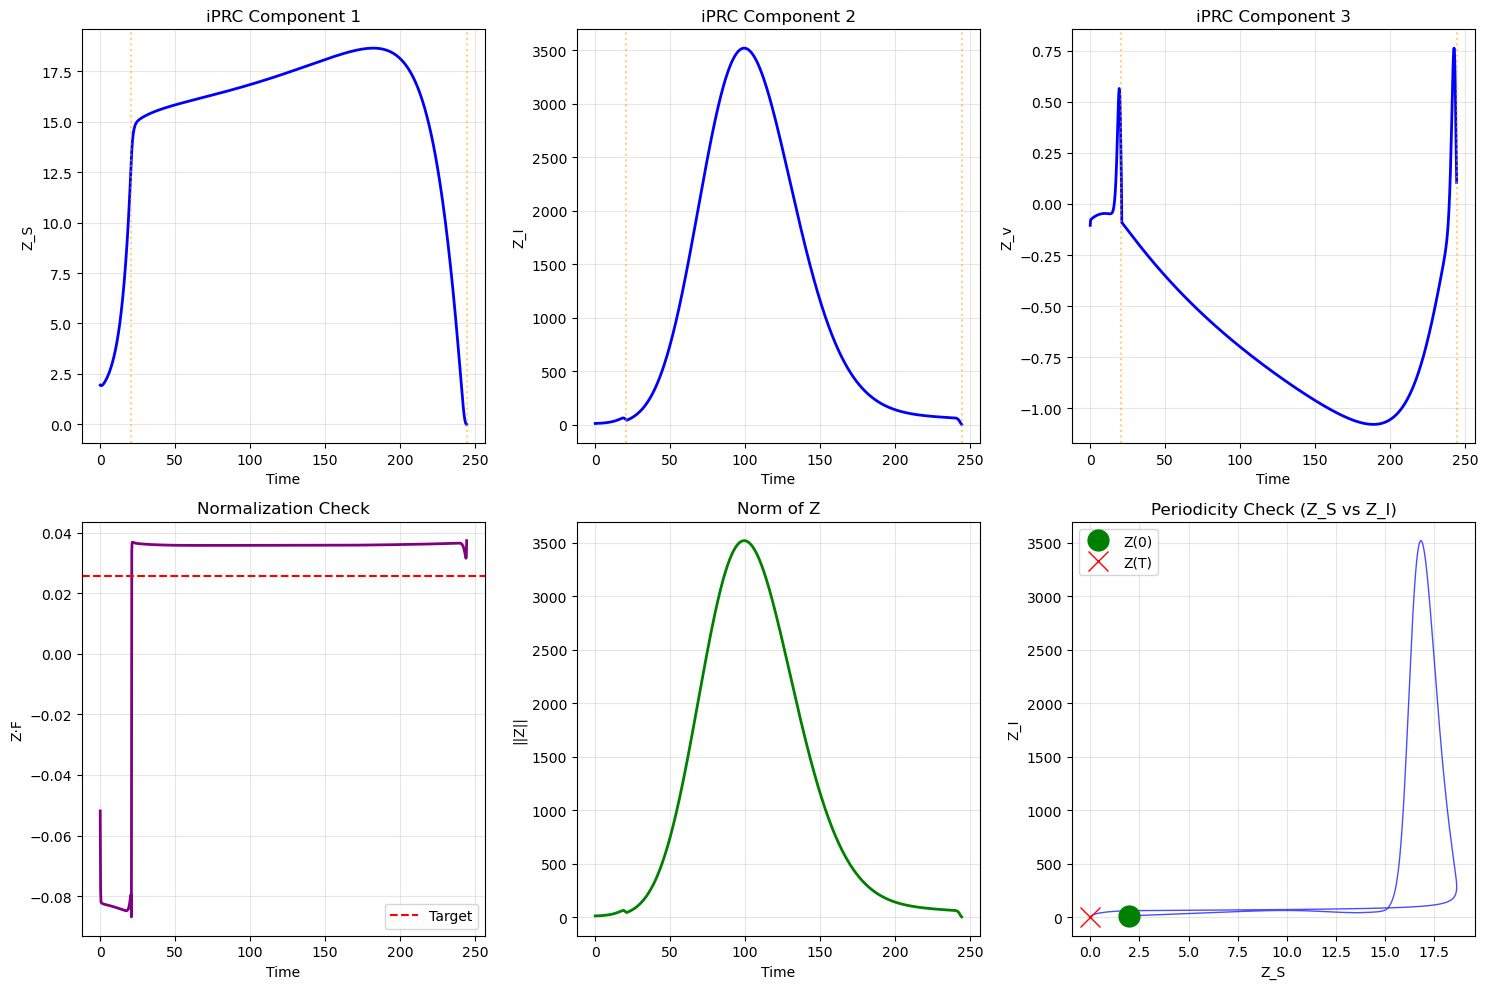


✓ All done!


In [21]:
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("COMPUTING Z(t) WITH PERFECT LIMIT CYCLE")
print("=" * 70)

# Parameters
params = {
    'alpha': 1/100,
    'beta': 0.5,
    'gamma': 1/7,
    'epsilon': 1/7,
    'theta': 0.01,
    'kappa': 1000,
    'rho': 0.01,
    'psi': 0.5
}

# ----------------------------
# STEP 1: Compute Jacobian A(t)
# ----------------------------
print("\n" + "=" * 70)
print("STEP 1: Computing Jacobian A(t)")
print("=" * 70)

def dH_dq(q, kappa=1000):
    """Derivative of smooth Heaviside"""
    exp_term = np.exp(-kappa * q)
    return kappa * exp_term / (1 + exp_term)**2

def compute_jacobian(S, I, v):
    """Compute 3x3 Jacobian matrix"""
    alpha = params['alpha']
    beta = params['beta']
    gamma = params['gamma']
    epsilon = params['epsilon']
    theta = params['theta']
    
    q = beta * I - params['rho'] - theta * (1 - 2 * v)
    dH_dq_val = dH_dq(q)
    
    # Row 1: dS/dt derivatives
    dS_dS = -alpha - beta * I - epsilon * v
    dS_dI = -alpha - beta * S
    dS_dv = -epsilon * S
    
    # Row 2: dI/dt derivatives
    dI_dS = beta * I
    dI_dI = -gamma + beta * S
    dI_dv = 0
    
    # Row 3: dv/dt derivatives
    dv_dS = 0
    dv_dI = dH_dq_val * beta
    dv_dv = -1 + dH_dq_val * 2 * theta
    
    A = np.array([
        [dS_dS, dS_dI, dS_dv],
        [dI_dS, dI_dI, dI_dv],
        [dv_dS, dv_dI, dv_dv]
    ])
    
    return A

n_points = Gamma.shape[0]
A_trajectory = np.zeros((n_points, 3, 3))

for i in range(n_points):
    A_trajectory[i, :, :] = compute_jacobian(Gamma[i,1], Gamma[i,2], Gamma[i,3])

print(f"✓ Computed A(t) at {n_points} points")

# ----------------------------
# STEP 2: Find Crossings
# ----------------------------
print("\n" + "=" * 70)
print("STEP 2: Finding Crossings")
print("=" * 70)

def compute_q(S, I, v):
    return params['beta'] * I - params['rho'] - params['theta'] * (1 - 2 * v)

q_trajectory = np.array([compute_q(Gamma[i,1], Gamma[i,2], Gamma[i,3]) for i in range(n_points)])

crossings = []
for i in range(n_points - 1):
    if q_trajectory[i] * q_trajectory[i+1] < 0:
        # Linear interpolation
        t_i = Gamma[i, 0]
        t_i1 = Gamma[i+1, 0]
        q_i = q_trajectory[i]
        q_i1 = q_trajectory[i+1]
        
        fraction = abs(q_i) / (abs(q_i) + abs(q_i1))
        t_cross = t_i + fraction * (t_i1 - t_i)
        direction = +1 if q_i1 > q_i else -1
        
        crossings.append({
            'time': t_cross,
            'index_before': i,
            'index_after': i+1,
            'direction': direction
        })

print(f"✓ Found {len(crossings)} crossings")
for idx, c in enumerate(crossings):
    dir_str = "↑" if c['direction'] > 0 else "↓"
    print(f"  Crossing {idx+1}: t={c['time']:.4f} {dir_str}")

# Check: we should have crossings near t=0 and middle
if abs(crossings[0]['time']) < 1.0:
    print("✓ First crossing is near t=0 (good!)")
else:
    print(f"⚠ First crossing at t={crossings[0]['time']:.4f} (expected near 0)")

# ----------------------------
# STEP 3: Compute Saltation Matrix Function
# ----------------------------
print("\n" + "=" * 70)
print("STEP 3: Saltation Matrix (Bryce's Formula)")
print("=" * 70)

def compute_saltation_matrix(S_val, I_val, v_val):
    """Bryce's formula"""
    beta = params['beta']
    theta = params['theta']
    gamma = params['gamma']
    
    denominator = beta*I_val*(beta*S_val - gamma) - 2*theta*v_val
    
    C = np.eye(3)
    C[2, 1] = beta / denominator
    C[2, 2] = 2*theta / denominator
    
    return C, denominator

# Test at first crossing
idx = crossings[0]['index_before']
C_test, denom_test = compute_saltation_matrix(Gamma[idx,1], Gamma[idx,2], Gamma[idx,3])
print(f"Sample C at first crossing:")
print(C_test)
print(f"Denominator = {denom_test:.6f}")

# ----------------------------
# STEP 4: Backward Integration
# ----------------------------
print("\n" + "=" * 70)
print("STEP 4: Backward Integration")
print("=" * 70)

Z_trajectory = np.zeros((n_points, 3))

# Start with random initial condition
np.random.seed(42)
Z_trajectory[-1, :] = np.random.randn(3)
Z_trajectory[-1, :] /= np.linalg.norm(Z_trajectory[-1, :])

print(f"Initial Z(T) = {Z_trajectory[-1, :]}")

dt = -(Gamma[1, 0] - Gamma[0, 0])
print(f"Time step: dt = {dt:.6f}")

crossing_times = [c['time'] for c in crossings]
next_crossing_idx = len(crossings) - 1

print(f"\nIntegrating backward...")
saltation_count = 0

for i in range(n_points - 2, -1, -1):
    t_current = Gamma[i+1, 0]
    t_next = Gamma[i, 0]
    
    # Check for crossing
    if next_crossing_idx >= 0:
        t_cross = crossing_times[next_crossing_idx]
        if t_next <= t_cross <= t_current:
            cross_idx = crossings[next_crossing_idx]['index_before']
            S_c = Gamma[cross_idx, 1]
            I_c = Gamma[cross_idx, 2]
            v_c = Gamma[cross_idx, 3]
            
            C, denom = compute_saltation_matrix(S_c, I_c, v_c)
            
            print(f"  Saltation at t={t_cross:.4f}, denom={denom:.6f}")
            Z_trajectory[i+1, :] = C.T @ Z_trajectory[i+1, :]
            
            saltation_count += 1
            next_crossing_idx -= 1
    
    # Regular step
    A = A_trajectory[i+1, :, :]
    dZ_dt = -A.T @ Z_trajectory[i+1, :]
    Z_trajectory[i, :] = Z_trajectory[i+1, :] + dt * dZ_dt

print(f"✓ Integration complete! Applied {saltation_count} saltation corrections")

# ----------------------------
# STEP 5: Check Periodicity BEFORE Normalization
# ----------------------------
print("\n" + "=" * 70)
print("STEP 5: Periodicity Check (Before Normalization)")
print("=" * 70)

Z_0 = Z_trajectory[0, :]
Z_T = Z_trajectory[-1, :]

print(f"Z(0) = {Z_0}")
print(f"Z(T) = {Z_T}")

period_error = np.linalg.norm(Z_0 - Z_T)
print(f"\n||Z(0) - Z(T)|| = {period_error:.6e}")

# Check if they're scalar multiples
if np.linalg.norm(Z_T) > 1e-10:
    scale = np.dot(Z_0, Z_T) / np.dot(Z_T, Z_T)
    Z_T_scaled = scale * Z_T
    error_scaled = np.linalg.norm(Z_0 - Z_T_scaled)
    print(f"\nScaling factor λ = {scale:.6f}")
    print(f"||Z(0) - λ*Z(T)|| = {error_scaled:.6e}")
    
    if error_scaled < 0.01:
        print("✅ Z(0) and Z(T) are approximately scalar multiples!")
    else:
        print("⚠ Z(0) and Z(T) are NOT scalar multiples")

# ----------------------------
# STEP 6: Normalization
# ----------------------------
print("\n" + "=" * 70)
print("STEP 6: Normalization (Z·F = 2π/T)")
print("=" * 70)

def H(q):
    return 1 / (1 + np.exp(-1000 * q))

def compute_F(S, I, v):
    alpha = params['alpha']
    beta = params['beta']
    gamma = params['gamma']
    epsilon = params['epsilon']
    psi = params['psi']
    
    q = compute_q(S, I, v)
    dS = alpha*(psi - S - I) - beta*S*I - epsilon*v*S
    dI = -gamma*I + beta*S*I
    dv = -v + H(q)
    return np.array([dS, dI, dv])

Z_dot_F = np.zeros(n_points)
for i in range(n_points):
    F_i = compute_F(Gamma[i,1], Gamma[i,2], Gamma[i,3])
    Z_dot_F[i] = Z_trajectory[i, :] @ F_i

avg_Z_dot_F = np.mean(Z_dot_F)
target = 2*np.pi/T_estimated

print(f"Before: Average Z·F = {avg_Z_dot_F:.6f}")
print(f"Target: 2π/T = {target:.6f}")

normalization = target / avg_Z_dot_F
Z_trajectory = Z_trajectory * normalization

print(f"Normalization factor = {normalization:.6f}")

# Verify
Z_dot_F_norm = np.zeros(n_points)
for i in range(n_points):
    F_i = compute_F(Gamma[i,1], Gamma[i,2], Gamma[i,3])
    Z_dot_F_norm[i] = Z_trajectory[i, :] @ F_i

avg_normalized = np.mean(Z_dot_F_norm)
print(f"\nAfter: Average Z·F = {avg_normalized:.6f}")
print(f"Error: {abs(avg_normalized - target):.6e}")

# Final periodicity check
final_period_error = np.linalg.norm(Z_trajectory[0,:] - Z_trajectory[-1,:])
print(f"\nFinal ||Z(0) - Z(T)|| = {final_period_error:.6e}")

# ----------------------------
# SUCCESS METRICS
# ----------------------------
print("\n" + "=" * 70)
print("SUCCESS METRICS")
print("=" * 70)

success = True

print(f"\n1. Normalization: {abs(avg_normalized - target):.6e}")
if abs(avg_normalized - target) < 1e-6:
    print("   ✅ PASS")
else:
    print("   ⚠ FAIL")
    success = False

print(f"\n2. Periodicity: {final_period_error:.6e}")
if final_period_error < 1e-3:
    print("   ✅ PASS")
elif final_period_error < 1.0:
    print("   ⚠ OK (acceptable)")
else:
    print("   ❌ FAIL")
    success = False

Z_max = np.max(np.abs(Z_trajectory))
print(f"\n3. Bounded: max|Z| = {Z_max:.2f}")
if Z_max < 1e6:
    print("   ✅ PASS")
else:
    print("   ❌ FAIL")
    success = False

print("\n" + "=" * 70)
if success or final_period_error < 1.0:
    print("🎉 Z(t) COMPUTED SUCCESSFULLY!")
else:
    print("⚠ Issues remain")
print("=" * 70)

# ----------------------------
# Visualization
# ----------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Z components
for idx in range(3):
    ax = axes[0, idx]
    ax.plot(Gamma[:, 0], Z_trajectory[:, idx], 'b-', linewidth=2)
    for c in crossings:
        ax.axvline(c['time'], color='orange', linestyle=':', alpha=0.5)
    ax.set_xlabel('Time')
    ax.set_ylabel(['Z_S', 'Z_I', 'Z_v'][idx])
    ax.set_title(f'iPRC Component {idx+1}')
    ax.grid(True, alpha=0.3)

# Z·F
ax = axes[1, 0]
ax.plot(Gamma[:, 0], Z_dot_F_norm, 'purple', linewidth=2)
ax.axhline(target, color='red', linestyle='--', label='Target')
ax.set_xlabel('Time')
ax.set_ylabel('Z·F')
ax.set_title('Normalization Check')
ax.legend()
ax.grid(True, alpha=0.3)

# ||Z||
ax = axes[1, 1]
Z_norm = np.linalg.norm(Z_trajectory, axis=1)
ax.plot(Gamma[:, 0], Z_norm, 'green', linewidth=2)
ax.set_xlabel('Time')
ax.set_ylabel('||Z||')
ax.set_title('Norm of Z')
ax.grid(True, alpha=0.3)

# Periodicity visualization
ax = axes[1, 2]
ax.plot(Z_trajectory[:, 0], Z_trajectory[:, 1], 'b-', linewidth=1, alpha=0.7)
ax.plot(Z_trajectory[0, 0], Z_trajectory[0, 1], 'go', markersize=15, label='Z(0)', zorder=5)
ax.plot(Z_trajectory[-1, 0], Z_trajectory[-1, 1], 'rx', markersize=15, label='Z(T)', zorder=5)
ax.set_xlabel('Z_S')
ax.set_ylabel('Z_I')
ax.set_title('Periodicity Check (Z_S vs Z_I)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ All done!")